# In this notebook, we will evalute our models predictions across the IVY League Conference Tournament

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")


In [2]:
# -- Read in data
ivy_preds = pd.read_csv('ivy_league_all_predictions_master.csv')
display(ivy_preds)
print(ivy_preds.columns)

,home_wrestler,away_wrestler,logreg_pred,logreg_winner,logreg_prob,dt_pred,dt_winner,dt_prob,xgb1_pred,xgb1_winner,xgb1_prob,xgb2_pred,xgb2_winner,xgb2_prob,weight_class,all_agree,avg_confidence
0,Davis Motyka,Greg Diakomihalis,1,Davis Motyka,0.7364,1,Davis Motyka,0.7460,1,Davis Motyka,0.6179,0,Greg Diakomihalis,0.6846,125,False,0.696225
1,Davis Motyka,Logan Brzozowski,1,Davis Motyka,0.5744,1,Davis Motyka,0.6111,1,Davis Motyka,0.5845,1,Davis Motyka,0.7888,125,True,0.639700
2,Sulayman Bah,Davis Motyka,0,Davis Motyka,0.5560,1,Sulayman Bah,0.6111,1,Sulayman Bah,0.7470,1,Sulayman Bah,0.8253,125,False,0.684850
3,Davis Motyka,Chase Yasutake,1,Davis Motyka,0.8255,1,Davis Motyka,0.8898,1,Davis Motyka,0.8581,1,Davis Motyka,0.9534,125,True,0.881700
4,Marc-Anthony McGowan,Davis Motyka,1,Marc-Anthony McGowan,0.5025,1,Marc-Anthony McGowan,0.6111,1,Marc-Anthony McGowan,0.7649,1,Marc-Anthony McGowan,0.6476,125,True,0.631525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Ashton Davis,Daniel Bittner,0,Daniel Bittner,0.6715,0,Daniel Bittner,0.5695,0,Daniel Bittner,0.5415,1,Ashton Davis,0.7979,285,False,0.645100
146,Alex Semenenko,Ashton Davis,1,Alex Semenenko,0.8644,1,Alex Semenenko,0.7460,1,Alex Semenenko,0.9011,1,Alex Semenenko,0.8480,285,True,0.839875
147,John Pardo,Daniel Bittner,1,John Pardo,0.6437,1,John Pardo,0.7460,1,John Pardo,0.8368,1,John Pardo,0.9531,285,True,0.794900
148,Alex Semenenko,John Pardo,1,Alex Semenenko,0.6332,1,Alex Semenenko,0.7460,1,Alex Semenenko,0.7711,0,John Pardo,0.5200,285,False,0.667575


Index(['home_wrestler', 'away_wrestler', 'logreg_pred', 'logreg_winner',
       'logreg_prob', 'dt_pred', 'dt_winner', 'dt_prob', 'xgb1_pred',
       'xgb1_winner', 'xgb1_prob', 'xgb2_pred', 'xgb2_winner', 'xgb2_prob',
       'weight_class', 'all_agree', 'avg_confidence'],
      dtype='object')


In [3]:
# ============================================
# FUNCTION TO EVALUATE A SINGLE WEIGHT CLASS (IVY LEAGUE VERSION)
# ============================================

def evaluate_weight_class_ivy(weight_class, actual_results, special_matches, 
                             predictions_df, conference="Ivy League", save_plots=False):
    """
    Evaluate all models for a specific weight class (adapted for Ivy League data format).
    
    Parameters:
    - weight_class: int (e.g., 125, 133, etc.)
    - actual_results: dict with (w1, w2, round_name) -> winner
    - special_matches: list of tuples for matches ending in injury/forfeit/DQ
    - predictions_df: dataframe with all predictions (Ivy League format)
    - conference: string for plot titles
    - save_plots: boolean to save plots to file
    
    Returns:
    - eval_df: detailed evaluation dataframe
    - summary_dict: dictionary with summary statistics
    """
    
    print("\n" + "="*100)
    print(f"🏋️  EVALUATING {weight_class}lbs - {conference} CONFERENCE")
    print("="*100)
    
    # Filter predictions for this weight class
    weight_preds = predictions_df[predictions_df['weight_class'] == weight_class].copy()
    
    if len(weight_preds) == 0:
        print(f"⚠️ No predictions found for {weight_class}lbs")
        return None, None
    
    print(f"\n📊 {weight_class}lbs predictions in dataset: {len(weight_preds)} matchups")
    
    # Create lookup dictionary
    pred_lookup = {}
    for _, row in weight_preds.iterrows():
        w1, w2 = row['home_wrestler'], row['away_wrestler']
        key = tuple(sorted([w1, w2]))
        pred_lookup[key] = row
    
    # Evaluate predictions
    results = []
    
    for (w1, w2, round_name), actual_winner in actual_results.items():
        key = tuple(sorted([w1, w2]))
        
        if key not in pred_lookup:
            print(f"⚠️ Warning: No prediction found for {w1} vs {w2} ({round_name})")
            continue
        
        row = pred_lookup[key]
        is_special = (w1, w2, round_name) in special_matches or (w2, w1, round_name) in special_matches
        result_type = 'SPECIAL' if is_special else 'REGULAR'
        
        # Determine home/away from the prediction
        home = row['home_wrestler']
        away = row['away_wrestler']
        
        results.append({
            'Match ID': f"{w1}_vs_{w2}_{round_name.replace(' ', '_')}",
            'Round': round_name,
            'Wrestler 1': w1,
            'Wrestler 2': w2,
            'Home': home,
            'Away': away,
            'Actual Winner': actual_winner,
            'Result Type': result_type,
            
            # Logistic Regression
            'LR Predicted': row['logreg_winner'],
            'LR Correct': row['logreg_winner'] == actual_winner,
            'LR Conf': row['logreg_prob'],
            
            # Decision Tree
            'DT Predicted': row['dt_winner'],
            'DT Correct': row['dt_winner'] == actual_winner,
            'DT Conf': row['dt_prob'],
            
            # XGBoost (no ranks)
            'XGB1 Predicted': row['xgb1_winner'],
            'XGB1 Correct': row['xgb1_winner'] == actual_winner,
            'XGB1 Conf': row['xgb1_prob'],
            
            # XGBoost (with ranks)
            'XGB2 Predicted': row['xgb2_winner'],
            'XGB2 Correct': row['xgb2_winner'] == actual_winner,
            'XGB2 Conf': row['xgb2_prob'],
        })
    
    eval_df = pd.DataFrame(results)
    
    if len(eval_df) == 0:
        print(f"⚠️ No matches evaluated for {weight_class}lbs")
        return None, None
    
    # Display detailed evaluation
    print("\n" + "="*100)
    print(f"📊 DETAILED EVALUATION - {weight_class}lbs ALL MATCHES")
    print("="*100)
    
    # Format for display
    display_df = eval_df.copy()
    for col in ['LR Conf', 'DT Conf', 'XGB1 Conf', 'XGB2 Conf']:
        display_df[col] = (display_df[col] * 100).round(1).astype(str) + '%'
    
    # Add emoji columns for display
    display_df['LR Correct'] = display_df['LR Correct'].map({True: '✅', False: '❌'})
    display_df['DT Correct'] = display_df['DT Correct'].map({True: '✅', False: '❌'})
    display_df['XGB1 Correct'] = display_df['XGB1 Correct'].map({True: '✅', False: '❌'})
    display_df['XGB2 Correct'] = display_df['XGB2 Correct'].map({True: '✅', False: '❌'})
    
    # Show relevant columns
    show_cols = ['Round', 'Wrestler 1', 'Wrestler 2', 'Actual Winner',
                 'LR Correct', 'LR Conf', 'DT Correct', 'DT Conf', 
                 'XGB1 Correct', 'XGB1 Conf', 'XGB2 Correct', 'XGB2 Conf']
    display(display_df[show_cols])
    
    # Calculate metrics
    def calculate_metrics(df, include_special=True):
        if not include_special:
            df = df[df['Result Type'] == 'REGULAR'].copy()
        
        if len(df) == 0:
            return {}
        
        metrics = {}
        models = [
            ('LR Correct', 'Logistic Regression'),
            ('DT Correct', 'Decision Tree'),
            ('XGB1 Correct', 'XGBoost (no ranks)'),
            ('XGB2 Correct', 'XGBoost (with ranks)')
        ]
        
        for col, name in models:
            correct_count = df[col].sum()
            total = len(df)
            accuracy = (correct_count / total * 100) if total > 0 else 0
            metrics[name] = {
                'correct': int(correct_count),
                'total': total,
                'accuracy': accuracy
            }
        
        return metrics
    
    all_metrics = calculate_metrics(eval_df, include_special=True)
    regular_metrics = calculate_metrics(eval_df, include_special=False)
    
    # Display metrics
    print("\n" + "="*100)
    print(f"📊 MODEL ACCURACY METRICS - {weight_class}lbs")
    print("="*100)
    
    print("\n🔴 INCLUDING ALL MATCHES:")
    if all_metrics:
        metrics_df_all = pd.DataFrame([
            {'Model': model, 'Correct': f"{metrics['correct']}/{metrics['total']}", 
             'Accuracy': f"{metrics['accuracy']:.1f}%"}
            for model, metrics in all_metrics.items()
        ])
        display(metrics_df_all)
    
    print("\n🟢 REGULAR MATCHES ONLY:")
    if regular_metrics:
        metrics_df_regular = pd.DataFrame([
            {'Model': model, 'Correct': f"{metrics['correct']}/{metrics['total']}", 
             'Accuracy': f"{metrics['accuracy']:.1f}%"}
            for model, metrics in regular_metrics.items()
        ])
        display(metrics_df_regular)
    
    # Bar plots
    if len(eval_df) > 0:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        
        all_df = eval_df.copy()
        regular_df = eval_df[eval_df['Result Type'] == 'REGULAR'].copy()
        
        models = [
            ('LR Correct', 'Logistic Regression'),
            ('DT Correct', 'Decision Tree'),
            ('XGB1 Correct', 'XGBoost (no ranks)'),
            ('XGB2 Correct', 'XGBoost (with ranks)')
        ]
        
        model_colors = {'Correct': '#2ecc71', 'Incorrect': '#e74c3c'}
        
        # Top row: ALL matches
        for idx, (col, name) in enumerate(models):
            correct_counts = all_df[col].sum()
            incorrect_counts = len(all_df) - correct_counts
            
            bars = axes[0, idx].bar(['Correct', 'Incorrect'], 
                                    [correct_counts, incorrect_counts],
                                    color=[model_colors['Correct'], model_colors['Incorrect']],
                                    edgecolor='black', linewidth=1)
            
            for bar, count in zip(bars, [correct_counts, incorrect_counts]):
                height = bar.get_height()
                axes[0, idx].text(bar.get_x() + bar.get_width()/2., height,
                                 f'{int(count)}', ha='center', va='bottom', fontweight='bold')
            
            accuracy = correct_counts / len(all_df) * 100
            axes[0, idx].set_title(f'{name}\nAccuracy: {accuracy:.1f}%', fontweight='bold')
            axes[0, idx].set_ylabel('Number of Matches')
            axes[0, idx].set_ylim(0, len(all_df) + 1)
            axes[0, idx].grid(axis='y', alpha=0.3)
        
        # Bottom row: REGULAR matches only
        if len(regular_df) > 0:
            for idx, (col, name) in enumerate(models):
                correct_counts = regular_df[col].sum()
                incorrect_counts = len(regular_df) - correct_counts
                
                bars = axes[1, idx].bar(['Correct', 'Incorrect'], 
                                        [correct_counts, incorrect_counts],
                                        color=[model_colors['Correct'], model_colors['Incorrect']],
                                        edgecolor='black', linewidth=1)
                
                for bar, count in zip(bars, [correct_counts, incorrect_counts]):
                    height = bar.get_height()
                    axes[1, idx].text(bar.get_x() + bar.get_width()/2., height,
                                     f'{int(count)}', ha='center', va='bottom', fontweight='bold')
                
                accuracy = correct_counts / len(regular_df) * 100
                axes[1, idx].set_title(f'{name}\nAccuracy: {accuracy:.1f}%', fontweight='bold')
                axes[1, idx].set_ylabel('Number of Matches')
                axes[1, idx].set_ylim(0, len(regular_df) + 1)
                axes[1, idx].grid(axis='y', alpha=0.3)
        else:
            for idx in range(4):
                axes[1, idx].text(0.5, 0.5, 'No Regular Matches', ha='center', va='center', 
                                 fontsize=14, transform=axes[1, idx].transAxes)
                axes[1, idx].set_title('No Data')
                axes[1, idx].set_xticks([])
                axes[1, idx].set_yticks([])
        
        axes[0, 0].annotate('ALL MATCHES', xy=(-0.3, 0.5), xycoords='axes fraction',
                            fontsize=12, fontweight='bold', rotation=90, va='center')
        axes[1, 0].annotate('REGULAR ONLY', xy=(-0.3, 0.5), xycoords='axes fraction',
                            fontsize=12, fontweight='bold', rotation=90, va='center')
        
        plt.suptitle(f'{weight_class}lbs - {conference} Model Performance', fontsize=16, y=1.02)
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(f'{conference}_{weight_class}lbs_performance_bars.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # Model Rankings
    print("\n" + "="*100)
    print(f"📊 MODEL RANKING - {weight_class}lbs")
    print("="*100)
    
    if all_metrics:
        ranking_df_all = pd.DataFrame([
            {'Model': model, 'Accuracy': f"{metrics['accuracy']:.1f}%", 
             'Correct': f"{metrics['correct']}/{metrics['total']}"}
            for model, metrics in sorted(all_metrics.items(), key=lambda x: x[1]['accuracy'], reverse=True)
        ])
        print("\n🏆 All Matches:")
        display(ranking_df_all)
    
    if regular_metrics:
        ranking_df_regular = pd.DataFrame([
            {'Model': model, 'Accuracy': f"{metrics['accuracy']:.1f}%", 
             'Correct': f"{metrics['correct']}/{metrics['total']}"}
            for model, metrics in sorted(regular_metrics.items(), key=lambda x: x[1]['accuracy'], reverse=True)
        ])
        print("\n🏆 Regular Matches Only:")
        display(ranking_df_regular)
    
    # Summary Statistics
    print("\n" + "="*100)
    print(f"📊 SUMMARY STATISTICS - {weight_class}lbs")
    print("="*100)
    
    total_matches = len(eval_df)
    special_matches_count = (eval_df['Result Type'] == 'SPECIAL').sum()
    regular_matches_count = total_matches - special_matches_count
    
    summary_stats = pd.DataFrame([
        {'Metric': 'Conference', 'Value': conference},
        {'Metric': 'Weight Class', 'Value': f'{weight_class}lbs'},
        {'Metric': 'Total Matches', 'Value': total_matches},
        {'Metric': 'Special Matches', 'Value': f"{special_matches_count} ({special_matches_count/total_matches*100:.1f}%)"},
        {'Metric': 'Regular Matches', 'Value': f"{regular_matches_count} ({regular_matches_count/total_matches*100:.1f}%)"},
    ])
    display(summary_stats)
    
    # Create summary dictionary
    summary_dict = {
        'weight_class': weight_class,
        'total_matches': total_matches,
        'special_matches': special_matches_count,
        'regular_matches': regular_matches_count,
        'all_metrics': all_metrics,
        'regular_metrics': regular_metrics,
        'ranking_all': ranking_df_all.iloc[0]['Model'] if not ranking_df_all.empty else None,
        'ranking_regular': ranking_df_regular.iloc[0]['Model'] if not ranking_df_regular.empty else None,
    }
    
    return eval_df, summary_dict



📋 SETTING UP 125lbs IVY LEAGUE TOURNAMENT RESULTS

📊 125lbs Results Summary:
   Total matches: 9
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Greg Diakomihalis,Logan Brzozowski,Greg Diakomihalis,REGULAR
1,Quarterfinal,Sulayman Bah,Chase Yasutake,Sulayman Bah,REGULAR
2,Semifinal,Davis Motyka,Greg Diakomihalis,Davis Motyka,REGULAR
3,Semifinal,Marc-Anthony McGowan,Sulayman Bah,Marc-Anthony McGowan,REGULAR
4,Consolation Semi,Sulayman Bah,Logan Brzozowski,Sulayman Bah,REGULAR
5,Consolation Semi,Greg Diakomihalis,Chase Yasutake,Greg Diakomihalis,REGULAR
6,3rd Place,Sulayman Bah,Greg Diakomihalis,Sulayman Bah,REGULAR
7,5th Place,Logan Brzozowski,Chase Yasutake,Logan Brzozowski,REGULAR
8,Championship,Marc-Anthony McGowan,Davis Motyka,Marc-Anthony McGowan,REGULAR



✅ No multiple meetings detected

🔍 EVALUATING 125lbs

🏋️  EVALUATING 125lbs - Ivy League CONFERENCE

📊 125lbs predictions in dataset: 15 matchups

📊 DETAILED EVALUATION - 125lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Greg Diakomihalis,Logan Brzozowski,Greg Diakomihalis,❌,67.6%,❌,74.6%,❌,68.8%,✅,78.3%
1,Quarterfinal,Sulayman Bah,Chase Yasutake,Sulayman Bah,✅,78.9%,✅,89.0%,✅,89.0%,✅,95.6%
2,Semifinal,Davis Motyka,Greg Diakomihalis,Davis Motyka,✅,73.6%,✅,74.6%,✅,61.8%,❌,68.5%
3,Semifinal,Marc-Anthony McGowan,Sulayman Bah,Marc-Anthony McGowan,✅,55.6%,✅,53.1%,✅,55.4%,✅,58.5%
4,Consolation Semi,Sulayman Bah,Logan Brzozowski,Sulayman Bah,✅,51.6%,✅,61.1%,✅,72.4%,✅,89.7%
5,Consolation Semi,Greg Diakomihalis,Chase Yasutake,Greg Diakomihalis,✅,63.1%,✅,89.0%,✅,80.0%,✅,93.2%
6,3rd Place,Sulayman Bah,Greg Diakomihalis,Sulayman Bah,✅,68.8%,✅,74.6%,✅,79.8%,✅,78.6%
7,5th Place,Logan Brzozowski,Chase Yasutake,Logan Brzozowski,✅,78.0%,✅,89.0%,✅,90.3%,✅,93.8%
8,Championship,Marc-Anthony McGowan,Davis Motyka,Marc-Anthony McGowan,✅,50.2%,✅,61.1%,✅,76.5%,✅,64.8%



📊 MODEL ACCURACY METRICS - 125lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,8/9,88.9%
1,Decision Tree,8/9,88.9%
2,XGBoost (no ranks),8/9,88.9%
3,XGBoost (with ranks),8/9,88.9%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,8/9,88.9%
1,Decision Tree,8/9,88.9%
2,XGBoost (no ranks),8/9,88.9%
3,XGBoost (with ranks),8/9,88.9%


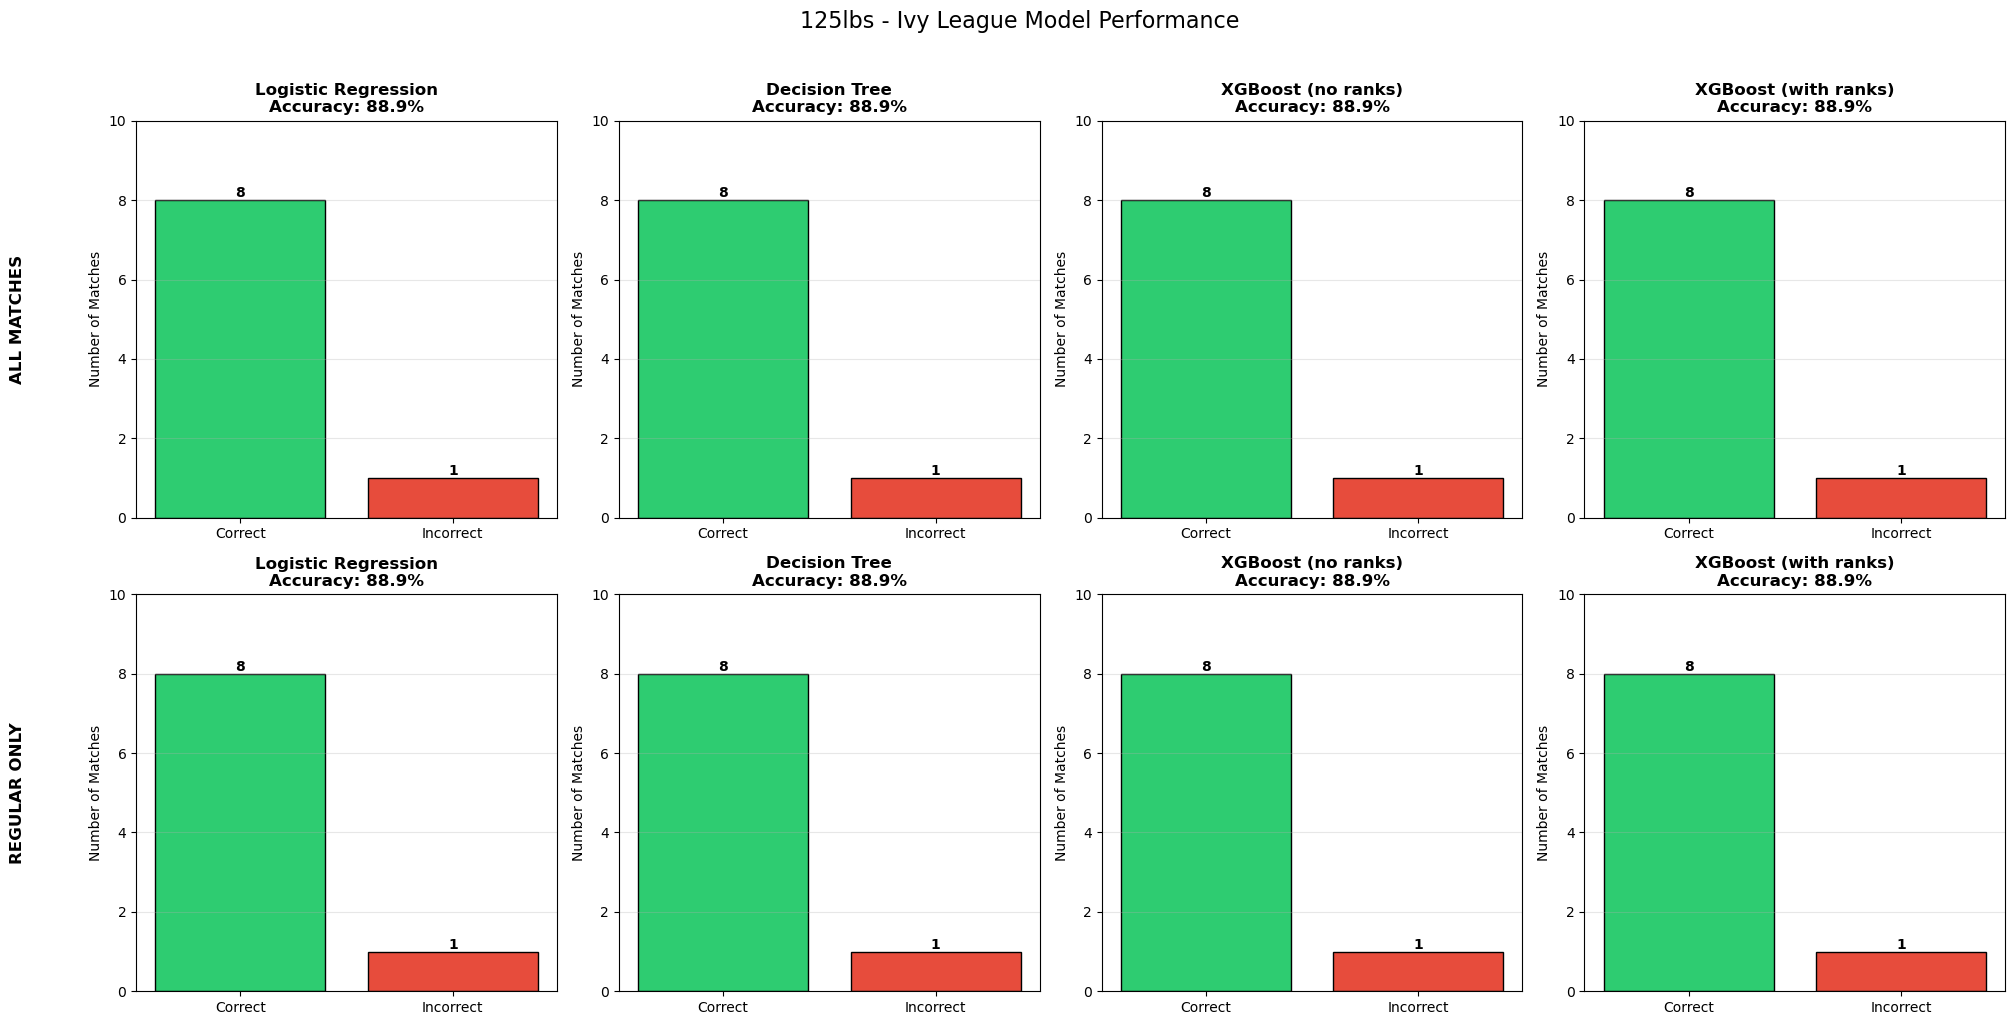


📊 MODEL RANKING - 125lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,Logistic Regression,88.9%,8/9
1,Decision Tree,88.9%,8/9
2,XGBoost (no ranks),88.9%,8/9
3,XGBoost (with ranks),88.9%,8/9



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,Logistic Regression,88.9%,8/9
1,Decision Tree,88.9%,8/9
2,XGBoost (no ranks),88.9%,8/9
3,XGBoost (with ranks),88.9%,8/9



📊 SUMMARY STATISTICS - 125lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,125lbs
2,Total Matches,9
3,Special Matches,0 (0.0%)
4,Regular Matches,9 (100.0%)



✅ 125lbs evaluation complete and added to overall results

📊 125lbs Quick Results:
   Logistic Regression: 8/9 (88.9%)
   Decision Tree: 8/9 (88.9%)
   XGBoost (no ranks): 8/9 (88.9%)
   XGBoost (with ranks): 8/9 (88.9%)



In [4]:
# ============================================
# 125lbs IVY LEAGUE RESULTS
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 125lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)

actual_results_125 = {
    # Quarterfinals
    ('Greg Diakomihalis', 'Logan Brzozowski', 'Quarterfinal'): 'Greg Diakomihalis',  # Fall 4:23
    ('Sulayman Bah', 'Chase Yasutake', 'Quarterfinal'): 'Sulayman Bah',  # MD 10-1
    
    # Semifinals
    ('Davis Motyka', 'Greg Diakomihalis', 'Semifinal'): 'Davis Motyka',  # SV 4-1
    ('Marc-Anthony McGowan', 'Sulayman Bah', 'Semifinal'): 'Marc-Anthony McGowan',  # Dec 9-2
    
    # Consolation Semis
    ('Sulayman Bah', 'Logan Brzozowski', 'Consolation Semi'): 'Sulayman Bah',  # Dec 8-4
    ('Greg Diakomihalis', 'Chase Yasutake', 'Consolation Semi'): 'Greg Diakomihalis',  # Dec 11-4
    
    # 3rd Place Match
    ('Sulayman Bah', 'Greg Diakomihalis', '3rd Place'): 'Sulayman Bah',  # Dec 11-2
    
    # 5th Place Match
    ('Logan Brzozowski', 'Chase Yasutake', '5th Place'): 'Logan Brzozowski',  # Dec 6-1
    
    # Championship Final
    ('Marc-Anthony McGowan', 'Davis Motyka', 'Championship'): 'Marc-Anthony McGowan',  # MD 10-2
}

# Track special matches (injury, forfeit, DQ) - none for 125lbs
special_matches_125 = []  # No special matches in 125lbs

print(f"\n📊 125lbs Results Summary:")
print(f"   Total matches: {len(actual_results_125)}")
print(f"   Special matches: {len(special_matches_125)}")

# Display actual matches
actual_matches_df_125 = []
for (w1, w2, round_name), winner in actual_results_125.items():
    is_special = (w1, w2, round_name) in special_matches_125 or (w2, w1, round_name) in special_matches_125
    actual_matches_df_125.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_125 = pd.DataFrame(actual_matches_df_125)
actual_matches_df_125['Round Order'] = actual_matches_df_125['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_125 = actual_matches_df_125.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_125)

# Check for multiple meetings
matchup_counter = Counter()
for (w1, w2, _) in actual_results_125.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_125.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# ============================================
# EVALUATE 125lbs
# ============================================

# Store results from each weight class
all_weight_results = []

print("\n" + "="*100)
print("🔍 EVALUATING 125lbs")
print("="*100)

eval_125, summary_125 = evaluate_weight_class_ivy(
    weight_class=125,
    actual_results=actual_results_125,
    special_matches=special_matches_125,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_125:
    all_weight_results.append(summary_125)
    print("\n✅ 125lbs evaluation complete and added to overall results")
    
    print("\n📊 125lbs Quick Results:")
    for model, metrics in summary_125['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 125lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 133lbs IVY LEAGUE TOURNAMENT RESULTS

📊 133lbs Results Summary:
   Total matches: 9
   Special matches: 0
   Note: 2 byes in quarterfinals (Tyler Ferrera, Evan Mougalian)


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Ethan Rivera,Coleman Nogle,Ethan Rivera,REGULAR
1,Quarterfinal,Evin Gursoy,Douglas Shipers,Evin Gursoy,REGULAR
2,Semifinal,Evan Mougalian,Ethan Rivera,Evan Mougalian,REGULAR
3,Semifinal,Tyler Ferrera,Evin Gursoy,Tyler Ferrera,REGULAR
4,Consolation Semi,Evin Gursoy,Coleman Nogle,Evin Gursoy,REGULAR
5,Consolation Semi,Ethan Rivera,Douglas Shipers,Ethan Rivera,REGULAR
6,3rd Place,Evin Gursoy,Ethan Rivera,Evin Gursoy,REGULAR
7,5th Place,Coleman Nogle,Douglas Shipers,Coleman Nogle,REGULAR
8,Championship,Tyler Ferrera,Evan Mougalian,Tyler Ferrera,REGULAR



✅ No multiple meetings detected

🔍 Checking for potential multiple meetings:
ℹ️ Evin Gursoy vs Ethan Rivera - 1 match (3rd Place)
ℹ️ Tyler Ferrera vs Evan Mougalian - 1 match (Championship)

🔍 EVALUATING 133lbs

🏋️  EVALUATING 133lbs - Ivy League CONFERENCE

📊 133lbs predictions in dataset: 15 matchups

📊 DETAILED EVALUATION - 133lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Ethan Rivera,Coleman Nogle,Ethan Rivera,✅,50.2%,✅,61.1%,✅,52.0%,✅,86.2%
1,Quarterfinal,Evin Gursoy,Douglas Shipers,Evin Gursoy,✅,82.7%,✅,89.0%,✅,91.4%,✅,96.6%
2,Semifinal,Evan Mougalian,Ethan Rivera,Evan Mougalian,✅,66.0%,✅,74.6%,✅,83.0%,✅,79.8%
3,Semifinal,Tyler Ferrera,Evin Gursoy,Tyler Ferrera,✅,50.4%,❌,61.1%,❌,73.3%,❌,59.6%
4,Consolation Semi,Evin Gursoy,Coleman Nogle,Evin Gursoy,✅,61.7%,✅,74.6%,✅,76.0%,✅,87.4%
5,Consolation Semi,Ethan Rivera,Douglas Shipers,Ethan Rivera,✅,75.0%,✅,89.0%,✅,85.3%,✅,94.3%
6,3rd Place,Evin Gursoy,Ethan Rivera,Evin Gursoy,✅,61.7%,✅,74.6%,✅,74.4%,✅,74.1%
7,5th Place,Coleman Nogle,Douglas Shipers,Coleman Nogle,✅,75.0%,✅,74.6%,✅,85.6%,✅,92.0%
8,Championship,Tyler Ferrera,Evan Mougalian,Tyler Ferrera,❌,54.2%,❌,61.1%,❌,67.0%,❌,60.5%



📊 MODEL ACCURACY METRICS - 133lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,8/9,88.9%
1,Decision Tree,7/9,77.8%
2,XGBoost (no ranks),7/9,77.8%
3,XGBoost (with ranks),7/9,77.8%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,8/9,88.9%
1,Decision Tree,7/9,77.8%
2,XGBoost (no ranks),7/9,77.8%
3,XGBoost (with ranks),7/9,77.8%


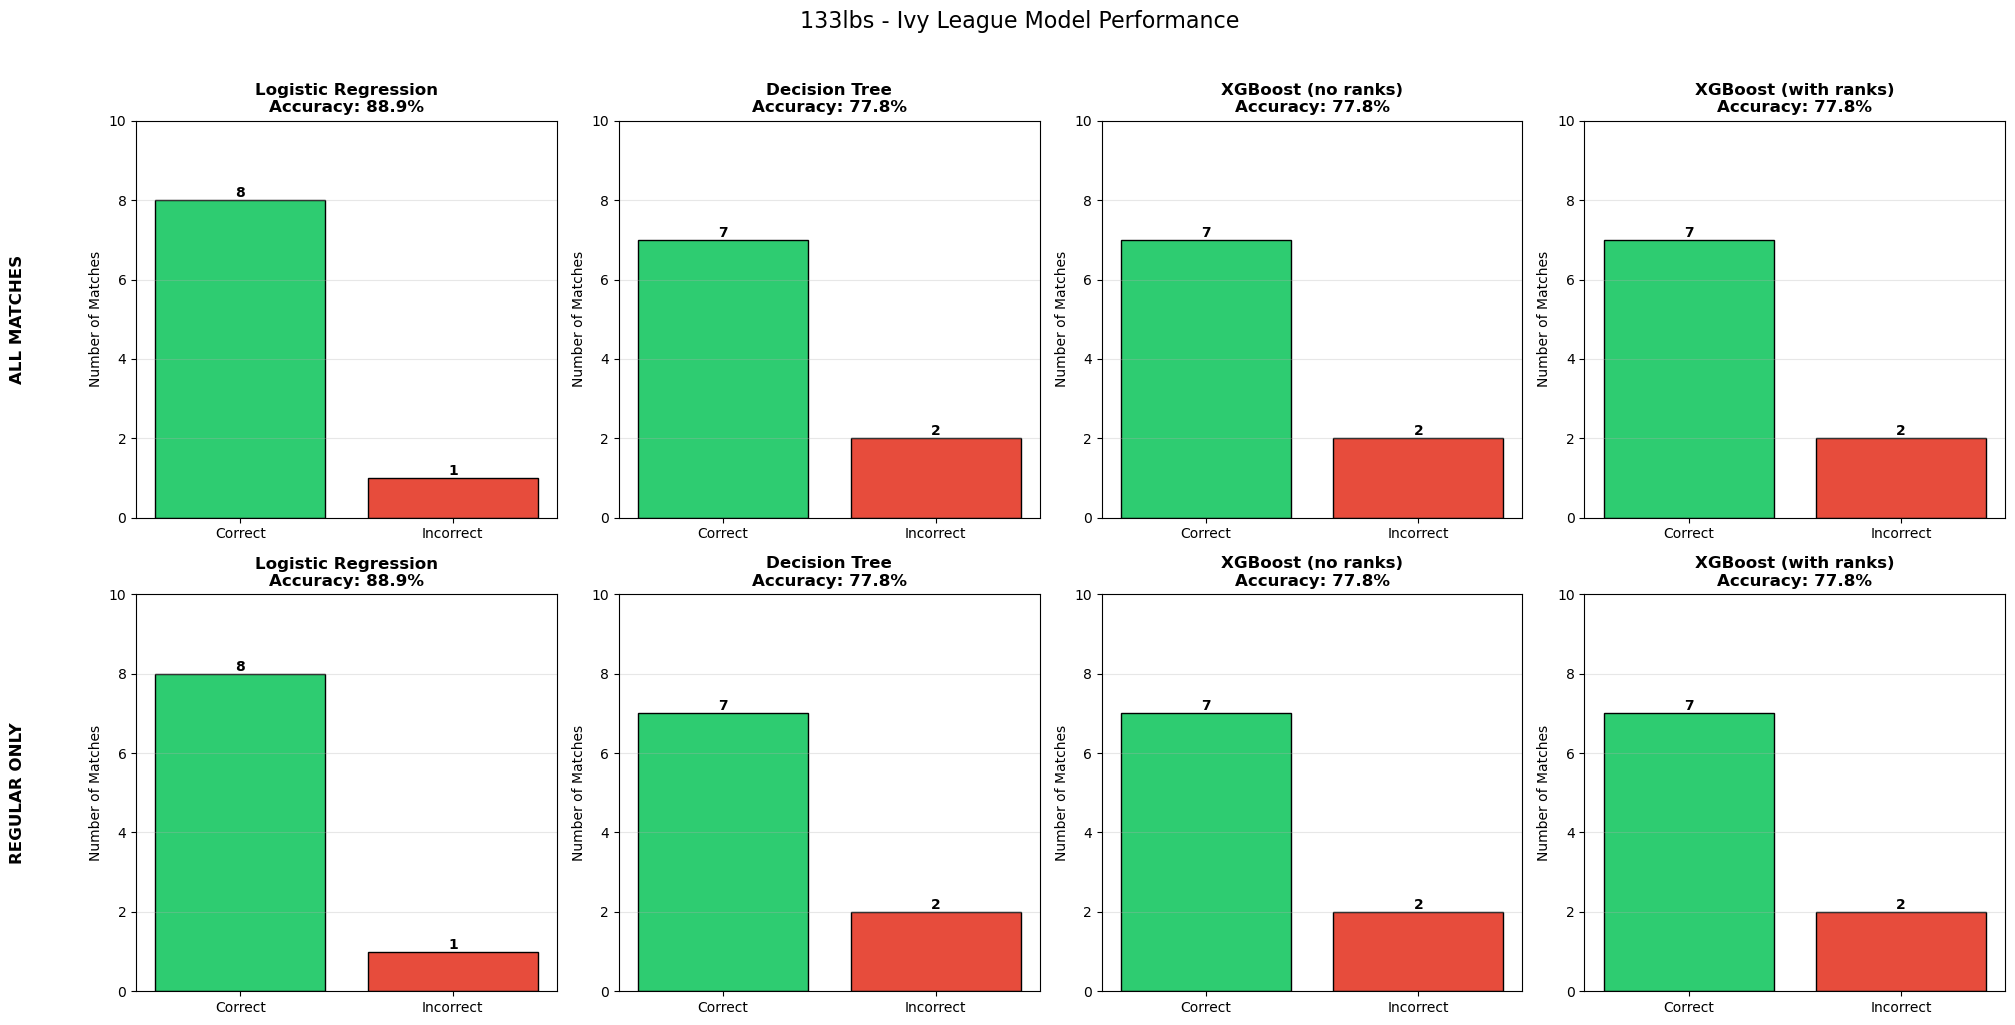


📊 MODEL RANKING - 133lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,Logistic Regression,88.9%,8/9
1,Decision Tree,77.8%,7/9
2,XGBoost (no ranks),77.8%,7/9
3,XGBoost (with ranks),77.8%,7/9



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,Logistic Regression,88.9%,8/9
1,Decision Tree,77.8%,7/9
2,XGBoost (no ranks),77.8%,7/9
3,XGBoost (with ranks),77.8%,7/9



📊 SUMMARY STATISTICS - 133lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,133lbs
2,Total Matches,9
3,Special Matches,0 (0.0%)
4,Regular Matches,9 (100.0%)



✅ 133lbs evaluation complete and added to overall results

📊 133lbs Quick Results:
   Logistic Regression: 8/9 (88.9%)
   Decision Tree: 7/9 (77.8%)
   XGBoost (no ranks): 7/9 (77.8%)
   XGBoost (with ranks): 7/9 (77.8%)



In [5]:
# ============================================
# 133lbs IVY LEAGUE RESULTS
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 133lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)

# Wrestlers in 133lbs:
# - Tyler Ferrera (Cornell)
# - Evan Mougalian (Pennsylvania)
# - Ethan Rivera (Princeton)
# - Evin Gursoy (Columbia)
# - Coleman Nogle (Harvard)
# - Douglas Shipers (Brown)

actual_results_133 = {
    # Quarterfinals
    ('Ethan Rivera', 'Coleman Nogle', 'Quarterfinal'): 'Ethan Rivera',  # MD 12-0
    ('Evin Gursoy', 'Douglas Shipers', 'Quarterfinal'): 'Evin Gursoy',  # TF 18-0 (3:42)
    # Note: Tyler Ferrera and Evan Mougalian had byes - no matches to record
    
    # Semifinals
    ('Evan Mougalian', 'Ethan Rivera', 'Semifinal'): 'Evan Mougalian',  # Dec 2-0
    ('Tyler Ferrera', 'Evin Gursoy', 'Semifinal'): 'Tyler Ferrera',  # SV 4-1
    
    # Consolation Semis
    ('Evin Gursoy', 'Coleman Nogle', 'Consolation Semi'): 'Evin Gursoy',  # Dec 1-0
    ('Ethan Rivera', 'Douglas Shipers', 'Consolation Semi'): 'Ethan Rivera',  # Fall 2:05
    
    # 3rd Place Match
    ('Evin Gursoy', 'Ethan Rivera', '3rd Place'): 'Evin Gursoy',  # Dec 2-0
    
    # 5th Place Match
    ('Coleman Nogle', 'Douglas Shipers', '5th Place'): 'Coleman Nogle',  # Fall 1:14
    
    # Championship Final
    ('Tyler Ferrera', 'Evan Mougalian', 'Championship'): 'Tyler Ferrera',  # MD 12-2
}

# Track special matches (injury, forfeit, DQ) - none for 133lbs
special_matches_133 = []  # No special matches mentioned

print(f"\n📊 133lbs Results Summary:")
print(f"   Total matches: {len(actual_results_133)}")
print(f"   Special matches: {len(special_matches_133)}")
print(f"   Note: 2 byes in quarterfinals (Tyler Ferrera, Evan Mougalian)")

# Display actual matches
actual_matches_df_133 = []
for (w1, w2, round_name), winner in actual_results_133.items():
    is_special = (w1, w2, round_name) in special_matches_133 or (w2, w1, round_name) in special_matches_133
    actual_matches_df_133.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_133 = pd.DataFrame(actual_matches_df_133)
actual_matches_df_133['Round Order'] = actual_matches_df_133['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_133 = actual_matches_df_133.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_133)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_133.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_133.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings
print("\n🔍 Checking for potential multiple meetings:")
# Evin Gursoy vs Ethan Rivera - they meet in Consolation Semi and 3rd Place? 
# Let's trace:
# - Consolation Semi: Evin Gursoy beat Coleman Nogle, Ethan Rivera beat Douglas Shipers
# - 3rd Place: Evin Gursoy beat Ethan Rivera
# So they meet ONCE in 3rd Place only
# No multiple meetings in this weight class

potential_multiples = [
    ('Evin Gursoy', 'Ethan Rivera'),
    ('Tyler Ferrera', 'Evan Mougalian'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_133.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# ============================================
# EVALUATE 133lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 133lbs")
print("="*100)

eval_133, summary_133 = evaluate_weight_class_ivy(
    weight_class=133,
    actual_results=actual_results_133,
    special_matches=special_matches_133,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_133:
    all_weight_results.append(summary_133)
    print("\n✅ 133lbs evaluation complete and added to overall results")
    
    print("\n📊 133lbs Quick Results:")
    for model, metrics in summary_133['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 133lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 141lbs IVY LEAGUE TOURNAMENT RESULTS

📊 141lbs Results Summary:
   Total matches: 9
   Special matches: 0
   Note: 2 byes in quarterfinals (Vince Cornella, CJ Composto)


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Matthew Martino,Lorenzo Frezza,Matthew Martino,REGULAR
1,Quarterfinal,Khimari Manns,Dante Frinzi,Khimari Manns,REGULAR
2,Semifinal,Vince Cornella,Matthew Martino,Vince Cornella,REGULAR
3,Semifinal,CJ Composto,Khimari Manns,CJ Composto,REGULAR
4,Consolation Semi,Lorenzo Frezza,Khimari Manns,Lorenzo Frezza,REGULAR
5,Consolation Semi,Matthew Martino,Dante Frinzi,Matthew Martino,REGULAR
6,3rd Place,Lorenzo Frezza,Matthew Martino,Lorenzo Frezza,REGULAR
7,5th Place,Dante Frinzi,Khimari Manns,Dante Frinzi,REGULAR
8,Championship,Vince Cornella,CJ Composto,Vince Cornella,REGULAR



⚠️ Multiple meetings detected:
   Lorenzo Frezza vs Matthew Martino: 2 matches
      Rounds:
        - Quarterfinal: Matthew Martino wins
        - 3rd Place: Lorenzo Frezza wins
   Dante Frinzi vs Khimari Manns: 2 matches
      Rounds:
        - Quarterfinal: Khimari Manns wins
        - 5th Place: Dante Frinzi wins

🔍 Checking for potential multiple meetings:
✅ Found: Matthew Martino vs Lorenzo Frezza - 2 matches
   - Quarterfinal: Matthew Martino wins
   - 3rd Place: Lorenzo Frezza wins
✅ Found: Khimari Manns vs Dante Frinzi - 2 matches
   - Quarterfinal: Khimari Manns wins
   - 5th Place: Dante Frinzi wins

📊 Detailed multiple meetings breakdown:

   Lorenzo Frezza vs Matthew Martino:
      Match 1: Quarterfinal - Matthew Martino wins
      Match 2: 3rd Place - Lorenzo Frezza wins

   Dante Frinzi vs Khimari Manns:
      Match 1: Quarterfinal - Khimari Manns wins
      Match 2: 5th Place - Dante Frinzi wins

🔍 EVALUATING 141lbs

🏋️  EVALUATING 141lbs - Ivy League CONFERENCE

📊 141

,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Matthew Martino,Lorenzo Frezza,Matthew Martino,❌,62.5%,❌,74.6%,❌,77.7%,❌,80.6%
1,Quarterfinal,Khimari Manns,Dante Frinzi,Khimari Manns,✅,67.1%,✅,74.6%,✅,73.9%,✅,50.6%
2,Semifinal,Vince Cornella,Matthew Martino,Vince Cornella,✅,76.5%,✅,89.0%,✅,88.0%,✅,92.3%
3,Semifinal,CJ Composto,Khimari Manns,CJ Composto,✅,61.2%,✅,74.6%,✅,75.1%,✅,92.2%
4,Consolation Semi,Lorenzo Frezza,Khimari Manns,Lorenzo Frezza,✅,54.1%,✅,61.1%,✅,67.1%,✅,89.1%
5,Consolation Semi,Matthew Martino,Dante Frinzi,Matthew Martino,✅,59.0%,✅,61.1%,✅,59.7%,✅,61.7%
6,3rd Place,Lorenzo Frezza,Matthew Martino,Lorenzo Frezza,✅,62.5%,✅,74.6%,✅,77.7%,✅,80.6%
7,5th Place,Dante Frinzi,Khimari Manns,Dante Frinzi,❌,67.1%,❌,74.6%,❌,73.9%,❌,50.6%
8,Championship,Vince Cornella,CJ Composto,Vince Cornella,✅,59.6%,❌,53.1%,✅,58.6%,✅,53.4%



📊 MODEL ACCURACY METRICS - 141lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,7/9,77.8%
1,Decision Tree,6/9,66.7%
2,XGBoost (no ranks),7/9,77.8%
3,XGBoost (with ranks),7/9,77.8%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,7/9,77.8%
1,Decision Tree,6/9,66.7%
2,XGBoost (no ranks),7/9,77.8%
3,XGBoost (with ranks),7/9,77.8%


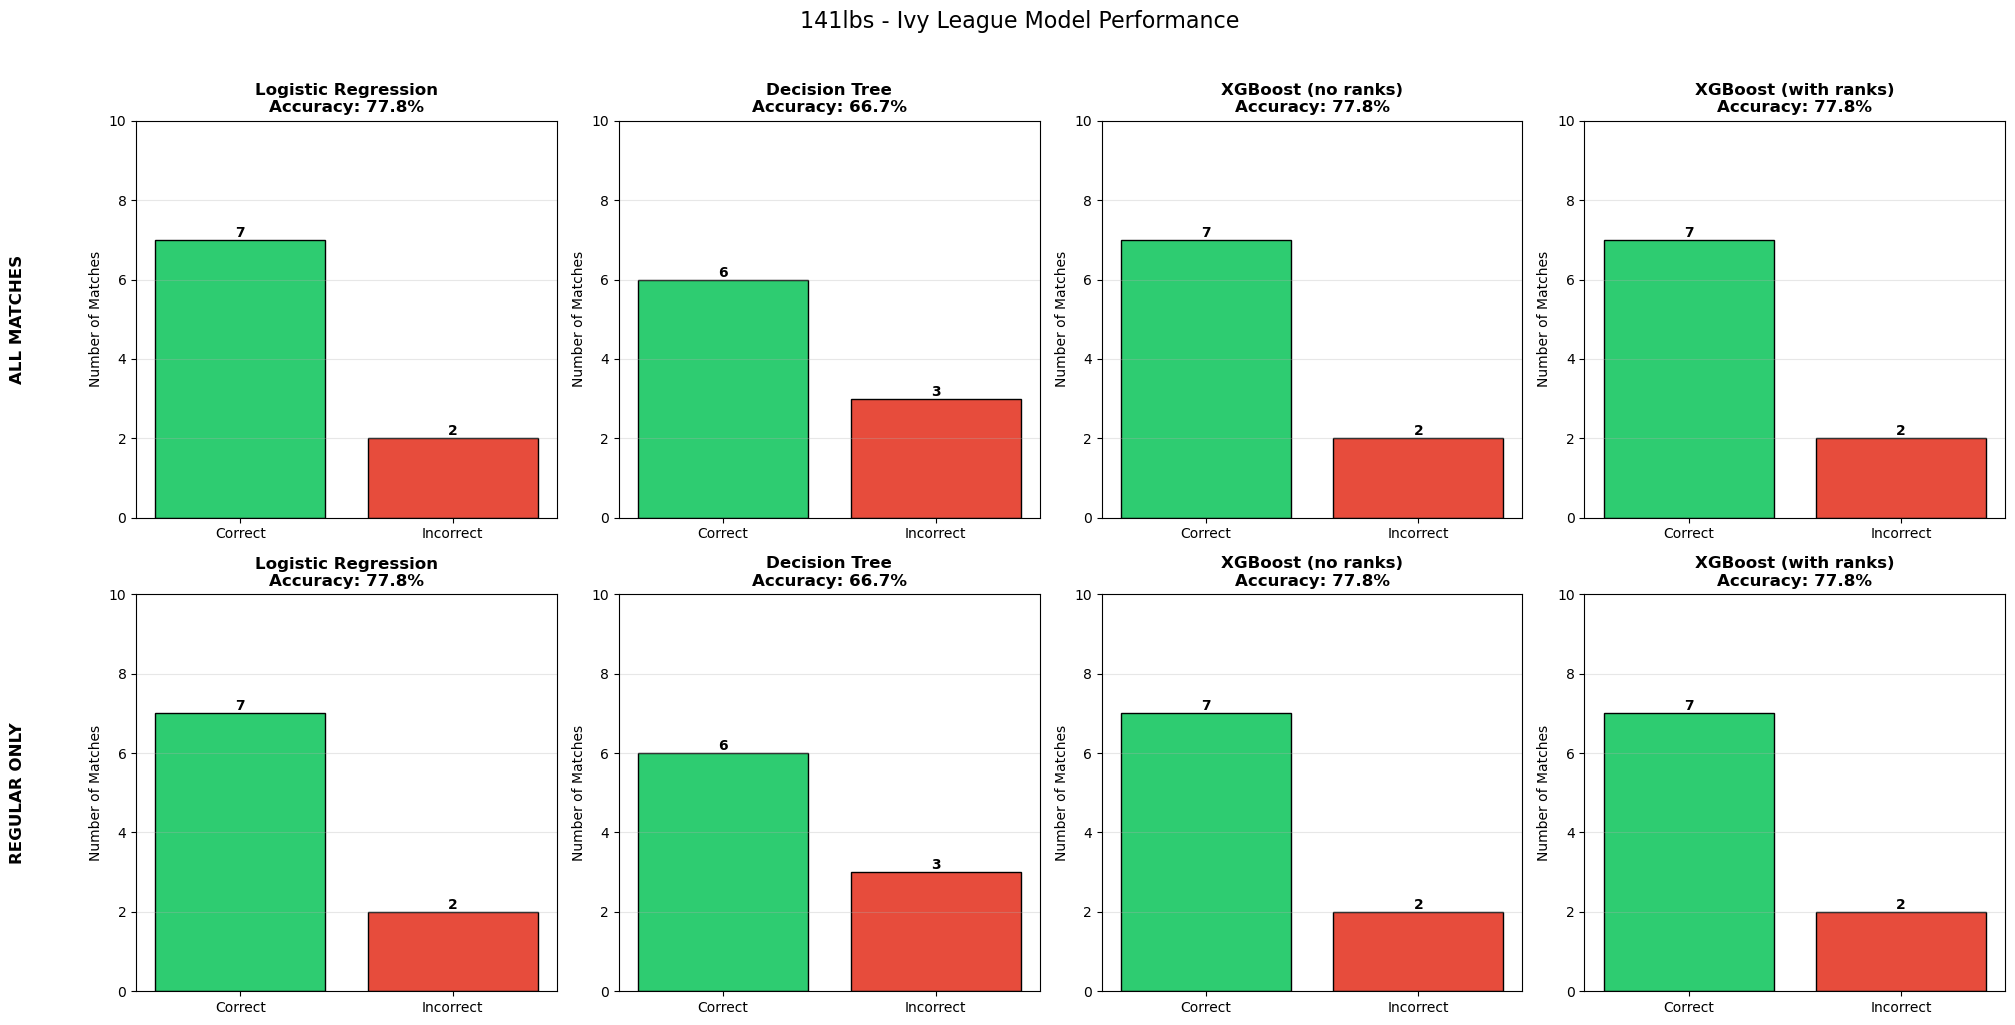


📊 MODEL RANKING - 141lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,Logistic Regression,77.8%,7/9
1,XGBoost (no ranks),77.8%,7/9
2,XGBoost (with ranks),77.8%,7/9
3,Decision Tree,66.7%,6/9



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,Logistic Regression,77.8%,7/9
1,XGBoost (no ranks),77.8%,7/9
2,XGBoost (with ranks),77.8%,7/9
3,Decision Tree,66.7%,6/9



📊 SUMMARY STATISTICS - 141lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,141lbs
2,Total Matches,9
3,Special Matches,0 (0.0%)
4,Regular Matches,9 (100.0%)



✅ 141lbs evaluation complete and added to overall results

📊 141lbs Quick Results:
   Logistic Regression: 7/9 (77.8%)
   Decision Tree: 6/9 (66.7%)
   XGBoost (no ranks): 7/9 (77.8%)
   XGBoost (with ranks): 7/9 (77.8%)



In [6]:
# ============================================
# 141lbs IVY LEAGUE RESULTS
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 141lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)

# Wrestlers in 141lbs:
# - Vince Cornella (Cornell)
# - CJ Composto (Pennsylvania)
# - Matthew Martino (Princeton)
# - Lorenzo Frezza (Columbia)
# - Khimari Manns (Brown)
# - Dante Frinzi (Harvard)

actual_results_141 = {
    # Quarterfinals
    ('Matthew Martino', 'Lorenzo Frezza', 'Quarterfinal'): 'Matthew Martino',  # Dec 10-3
    ('Khimari Manns', 'Dante Frinzi', 'Quarterfinal'): 'Khimari Manns',  # Dec 4-2
    # Note: Vince Cornella and CJ Composto had byes - no matches to record
    
    # Semifinals
    ('Vince Cornella', 'Matthew Martino', 'Semifinal'): 'Vince Cornella',  # MD 14-3
    ('CJ Composto', 'Khimari Manns', 'Semifinal'): 'CJ Composto',  # Dec 14-11
    
    # Consolation Semis
    ('Lorenzo Frezza', 'Khimari Manns', 'Consolation Semi'): 'Lorenzo Frezza',  # Dec 5-1
    ('Matthew Martino', 'Dante Frinzi', 'Consolation Semi'): 'Matthew Martino',  # Dec 10-8
    
    # 3rd Place Match
    ('Lorenzo Frezza', 'Matthew Martino', '3rd Place'): 'Lorenzo Frezza',  # Dec 8-5
    
    # 5th Place Match
    ('Dante Frinzi', 'Khimari Manns', '5th Place'): 'Dante Frinzi',  # Dec (score not specified)
    
    # Championship Final
    ('Vince Cornella', 'CJ Composto', 'Championship'): 'Vince Cornella',  # Dec 5-3
}

# Track special matches (injury, forfeit, DQ) - none for 141lbs
special_matches_141 = []  # No special matches mentioned

print(f"\n📊 141lbs Results Summary:")
print(f"   Total matches: {len(actual_results_141)}")
print(f"   Special matches: {len(special_matches_141)}")
print(f"   Note: 2 byes in quarterfinals (Vince Cornella, CJ Composto)")

# Display actual matches
actual_matches_df_141 = []
for (w1, w2, round_name), winner in actual_results_141.items():
    is_special = (w1, w2, round_name) in special_matches_141 or (w2, w1, round_name) in special_matches_141
    actual_matches_df_141.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_141 = pd.DataFrame(actual_matches_df_141)
actual_matches_df_141['Round Order'] = actual_matches_df_141['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_141 = actual_matches_df_141.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_141)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_141.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_141.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings
print("\n🔍 Checking for potential multiple meetings:")
# Matthew Martino vs Lorenzo Frezza - they meet in Quarterfinal and 3rd Place? 
# Let's trace:
# - Quarterfinal: Matthew Martino beat Lorenzo Frezza (10-3)
# - 3rd Place: Lorenzo Frezza beat Matthew Martino (8-5)
# This IS a multiple meeting! They wrestle twice with different outcomes

potential_multiples = [
    ('Matthew Martino', 'Lorenzo Frezza'),
    ('Khimari Manns', 'Dante Frinzi'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_141.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# If multiple meetings found, show detailed breakdown
if multiple_meetings:
    print("\n📊 Detailed multiple meetings breakdown:")
    for matchup in multiple_meetings:
        print(f"\n   {matchup}:")
        w1, w2 = matchup.split(' vs ')
        matches = [(r, win) for (a, b, r), win in actual_results_141.items() 
                   if (a == w1 and b == w2) or (a == w2 and b == w1)]
        for i, (round_name, winner) in enumerate(matches, 1):
            print(f"      Match {i}: {round_name} - {winner} wins")

# ============================================
# EVALUATE 141lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 141lbs")
print("="*100)

eval_141, summary_141 = evaluate_weight_class_ivy(
    weight_class=141,
    actual_results=actual_results_141,
    special_matches=special_matches_141,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_141:
    all_weight_results.append(summary_141)
    print("\n✅ 141lbs evaluation complete and added to overall results")
    
    print("\n📊 141lbs Quick Results:")
    for model, metrics in summary_141['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 141lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 149lbs IVY LEAGUE TOURNAMENT RESULTS

📊 149lbs Results Summary:
   Total matches: 9
   Special matches: 0
   Note: 2 byes in quarterfinals (Jaxon Joy, Cross Wasilewski)


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Jack Crook,Richard Fedalen,Jack Crook,REGULAR
1,Quarterfinal,Eligh Rivera,Austin McBurney,Eligh Rivera,REGULAR
2,Semifinal,Jaxon Joy,Jack Crook,Jaxon Joy,REGULAR
3,Semifinal,Cross Wasilewski,Eligh Rivera,Cross Wasilewski,REGULAR
4,Consolation Semi,Eligh Rivera,Richard Fedalen,Eligh Rivera,REGULAR
5,Consolation Semi,Austin McBurney,Jack Crook,Austin McBurney,REGULAR
6,3rd Place,Austin McBurney,Eligh Rivera,Austin McBurney,REGULAR
7,5th Place,Jack Crook,Richard Fedalen,Jack Crook,REGULAR
8,Championship,Jaxon Joy,Cross Wasilewski,Jaxon Joy,REGULAR



⚠️ Multiple meetings detected:
   Jack Crook vs Richard Fedalen: 2 matches
      Rounds:
        - Quarterfinal: Jack Crook wins
        - 5th Place: Jack Crook wins
   Austin McBurney vs Eligh Rivera: 2 matches
      Rounds:
        - Quarterfinal: Eligh Rivera wins
        - 3rd Place: Austin McBurney wins

🔍 Checking for potential multiple meetings:
✅ Found: Jack Crook vs Richard Fedalen - 2 matches
   - Quarterfinal: Jack Crook wins
   - 5th Place: Jack Crook wins
✅ Found: Eligh Rivera vs Austin McBurney - 2 matches
   - Quarterfinal: Eligh Rivera wins
   - 3rd Place: Austin McBurney wins

📊 Detailed multiple meetings breakdown:

   Jack Crook vs Richard Fedalen:
      Match 1: Quarterfinal - Jack Crook wins
      Match 2: 5th Place - Jack Crook wins

   Austin McBurney vs Eligh Rivera:
      Match 1: Quarterfinal - Eligh Rivera wins
      Match 2: 3rd Place - Austin McBurney wins

🔍 EVALUATING 149lbs

🏋️  EVALUATING 149lbs - Ivy League CONFERENCE

📊 149lbs predictions in dataset:

,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Jack Crook,Richard Fedalen,Jack Crook,✅,63.0%,✅,85.6%,✅,72.6%,❌,69.2%
1,Quarterfinal,Eligh Rivera,Austin McBurney,Eligh Rivera,✅,50.2%,❌,53.1%,❌,53.0%,✅,82.2%
2,Semifinal,Jaxon Joy,Jack Crook,Jaxon Joy,✅,64.3%,✅,74.6%,✅,77.3%,✅,90.8%
3,Semifinal,Cross Wasilewski,Eligh Rivera,Cross Wasilewski,✅,67.4%,✅,74.6%,✅,77.7%,✅,84.4%
4,Consolation Semi,Eligh Rivera,Richard Fedalen,Eligh Rivera,✅,58.1%,✅,53.1%,✅,53.9%,❌,55.6%
5,Consolation Semi,Austin McBurney,Jack Crook,Austin McBurney,❌,55.5%,❌,61.1%,❌,57.3%,❌,56.1%
6,3rd Place,Austin McBurney,Eligh Rivera,Austin McBurney,❌,50.2%,✅,53.1%,✅,53.0%,❌,82.2%
7,5th Place,Jack Crook,Richard Fedalen,Jack Crook,✅,63.0%,✅,85.6%,✅,72.6%,❌,69.2%
8,Championship,Jaxon Joy,Cross Wasilewski,Jaxon Joy,✅,52.0%,✅,61.1%,✅,70.7%,✅,74.4%



📊 MODEL ACCURACY METRICS - 149lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,7/9,77.8%
1,Decision Tree,7/9,77.8%
2,XGBoost (no ranks),7/9,77.8%
3,XGBoost (with ranks),4/9,44.4%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,7/9,77.8%
1,Decision Tree,7/9,77.8%
2,XGBoost (no ranks),7/9,77.8%
3,XGBoost (with ranks),4/9,44.4%


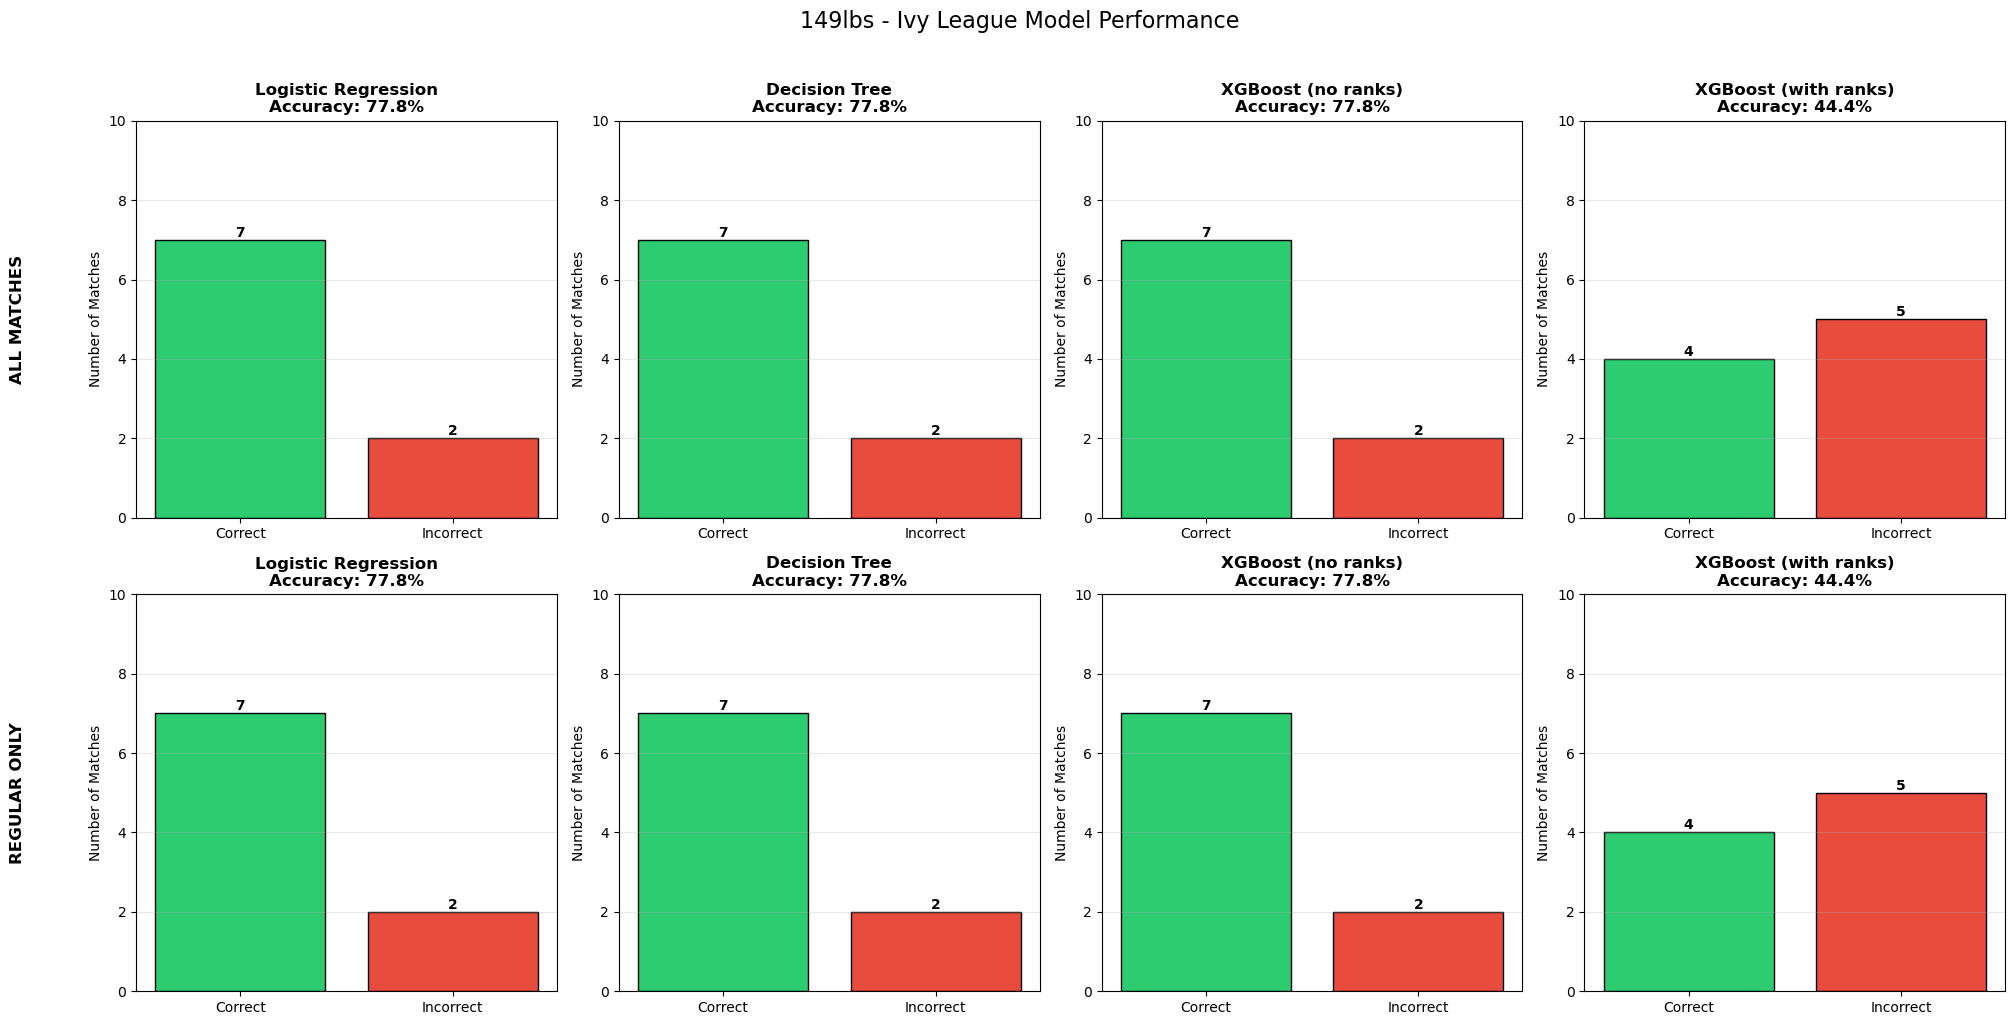


📊 MODEL RANKING - 149lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,Logistic Regression,77.8%,7/9
1,Decision Tree,77.8%,7/9
2,XGBoost (no ranks),77.8%,7/9
3,XGBoost (with ranks),44.4%,4/9



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,Logistic Regression,77.8%,7/9
1,Decision Tree,77.8%,7/9
2,XGBoost (no ranks),77.8%,7/9
3,XGBoost (with ranks),44.4%,4/9



📊 SUMMARY STATISTICS - 149lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,149lbs
2,Total Matches,9
3,Special Matches,0 (0.0%)
4,Regular Matches,9 (100.0%)



✅ 149lbs evaluation complete and added to overall results

📊 149lbs Quick Results:
   Logistic Regression: 7/9 (77.8%)
   Decision Tree: 7/9 (77.8%)
   XGBoost (no ranks): 7/9 (77.8%)
   XGBoost (with ranks): 4/9 (44.4%)



In [7]:
# ============================================
# 149lbs IVY LEAGUE RESULTS
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 149lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)

# Wrestlers in 149lbs:
# - Jaxon Joy (Cornell)
# - Cross Wasilewski (Pennsylvania)
# - Jack Crook (Harvard)
# - Eligh Rivera (Princeton)
# - Austin McBurney (Brown)
# - Richard Fedalen (Columbia)

actual_results_149 = {
    # Quarterfinals
    ('Jack Crook', 'Richard Fedalen', 'Quarterfinal'): 'Jack Crook',  # MD 17-4
    ('Eligh Rivera', 'Austin McBurney', 'Quarterfinal'): 'Eligh Rivera',  # Dec 10-4
    # Note: Jaxon Joy and Cross Wasilewski had byes - no matches to record
    
    # Semifinals
    ('Jaxon Joy', 'Jack Crook', 'Semifinal'): 'Jaxon Joy',  # TF 18-1 (4:57)
    ('Cross Wasilewski', 'Eligh Rivera', 'Semifinal'): 'Cross Wasilewski',  # Dec 5-0
    
    # Consolation Semis
    ('Eligh Rivera', 'Richard Fedalen', 'Consolation Semi'): 'Eligh Rivera',  # Dec 4-3
    ('Austin McBurney', 'Jack Crook', 'Consolation Semi'): 'Austin McBurney',  # Dec 12-2
    
    # 3rd Place Match
    ('Austin McBurney', 'Eligh Rivera', '3rd Place'): 'Austin McBurney',  # Dec 8-2
    
    # 5th Place Match
    ('Jack Crook', 'Richard Fedalen', '5th Place'): 'Jack Crook',  # Dec 12-7
    
    # Championship Final
    ('Jaxon Joy', 'Cross Wasilewski', 'Championship'): 'Jaxon Joy',  # Dec 2-0
}

# Track special matches (injury, forfeit, DQ) - none for 149lbs
special_matches_149 = []  # No special matches mentioned

print(f"\n📊 149lbs Results Summary:")
print(f"   Total matches: {len(actual_results_149)}")
print(f"   Special matches: {len(special_matches_149)}")
print(f"   Note: 2 byes in quarterfinals (Jaxon Joy, Cross Wasilewski)")

# Display actual matches
actual_matches_df_149 = []
for (w1, w2, round_name), winner in actual_results_149.items():
    is_special = (w1, w2, round_name) in special_matches_149 or (w2, w1, round_name) in special_matches_149
    actual_matches_df_149.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_149 = pd.DataFrame(actual_matches_df_149)
actual_matches_df_149['Round Order'] = actual_matches_df_149['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_149 = actual_matches_df_149.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_149)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_149.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_149.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings
print("\n🔍 Checking for potential multiple meetings:")
# Jack Crook vs Richard Fedalen - they meet in Quarterfinal and 5th Place?
# Let's trace:
# - Quarterfinal: Jack Crook beat Richard Fedalen (MD 17-4)
# - 5th Place: Jack Crook beat Richard Fedalen (Dec 12-7)
# This IS a multiple meeting! They wrestle twice with same outcome (both Crook wins)

# Eligh Rivera vs Austin McBurney - they meet in Quarterfinal and 3rd Place?
# - Quarterfinal: Eligh Rivera beat Austin McBurney (Dec 10-4)
# - 3rd Place: Austin McBurney beat Eligh Rivera (Dec 8-2)
# This IS a multiple meeting! They wrestle twice with different outcomes

potential_multiples = [
    ('Jack Crook', 'Richard Fedalen'),
    ('Eligh Rivera', 'Austin McBurney'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_149.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# If multiple meetings found, show detailed breakdown
if multiple_meetings:
    print("\n📊 Detailed multiple meetings breakdown:")
    for matchup in multiple_meetings:
        print(f"\n   {matchup}:")
        w1, w2 = matchup.split(' vs ')
        matches = [(r, win) for (a, b, r), win in actual_results_149.items() 
                   if (a == w1 and b == w2) or (a == w2 and b == w1)]
        for i, (round_name, winner) in enumerate(matches, 1):
            print(f"      Match {i}: {round_name} - {winner} wins")

# ============================================
# EVALUATE 149lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 149lbs")
print("="*100)

eval_149, summary_149 = evaluate_weight_class_ivy(
    weight_class=149,
    actual_results=actual_results_149,
    special_matches=special_matches_149,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_149:
    all_weight_results.append(summary_149)
    print("\n✅ 149lbs evaluation complete and added to overall results")
    
    print("\n📊 149lbs Quick Results:")
    for model, metrics in summary_149['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 149lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 157lbs IVY LEAGUE TOURNAMENT RESULTS

📊 157lbs Results Summary:
   Total matches: 9
   Special matches: 0
   Note: 2 byes in quarterfinals (Jude Swisher, Meyer Shapiro)
   ⚠️ UPSET ALERT: #1 seed Meyer Shapiro lost in finals to Jude Swisher!


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Kai Owen,Ethan Mojena,Kai Owen,REGULAR
1,Quarterfinal,Jimmy Harrington,Rocco Camillaci,Jimmy Harrington,REGULAR
2,Semifinal,Meyer Shapiro,Kai Owen,Meyer Shapiro,REGULAR
3,Semifinal,Jude Swisher,Jimmy Harrington,Jude Swisher,REGULAR
4,Consolation Semi,Jimmy Harrington,Ethan Mojena,Jimmy Harrington,REGULAR
5,Consolation Semi,Kai Owen,Rocco Camillaci,Kai Owen,REGULAR
6,3rd Place,Kai Owen,Jimmy Harrington,Kai Owen,REGULAR
7,5th Place,Ethan Mojena,Rocco Camillaci,Ethan Mojena,REGULAR
8,Championship,Jude Swisher,Meyer Shapiro,Jude Swisher,REGULAR



✅ No multiple meetings detected

🔍 Checking for potential multiple meetings:
ℹ️ Kai Owen vs Jimmy Harrington - 1 match (3rd Place)
ℹ️ Jimmy Harrington vs Ethan Mojena - 1 match (Consolation Semi)
ℹ️ Kai Owen vs Rocco Camillaci - 1 match (Consolation Semi)

🔍 Analyzing tournament path for potential multiple meetings:

   Jude Swisher:
      Semifinal: Won vs Jimmy Harrington
      Championship: Won vs Meyer Shapiro

   Meyer Shapiro:
      Semifinal: Won vs Kai Owen
      Championship: Lost vs Jude Swisher

   Kai Owen:
      Quarterfinal: Won vs Ethan Mojena
      Semifinal: Lost vs Meyer Shapiro
      Consolation Semi: Won vs Rocco Camillaci
      3rd Place: Won vs Jimmy Harrington

   Jimmy Harrington:
      Quarterfinal: Won vs Rocco Camillaci
      Semifinal: Lost vs Jude Swisher
      Consolation Semi: Won vs Ethan Mojena
      3rd Place: Lost vs Kai Owen

   Ethan Mojena:
      Quarterfinal: Lost vs Kai Owen
      Consolation Semi: Lost vs Jimmy Harrington
      5th Place: Won v

,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Kai Owen,Ethan Mojena,Kai Owen,✅,59.4%,✅,61.1%,✅,72.8%,✅,88.3%
1,Quarterfinal,Jimmy Harrington,Rocco Camillaci,Jimmy Harrington,✅,73.5%,✅,74.6%,✅,80.9%,✅,81.4%
2,Semifinal,Meyer Shapiro,Kai Owen,Meyer Shapiro,✅,72.2%,✅,85.6%,✅,78.5%,✅,85.8%
3,Semifinal,Jude Swisher,Jimmy Harrington,Jude Swisher,✅,50.2%,✅,61.1%,✅,53.8%,✅,86.0%
4,Consolation Semi,Jimmy Harrington,Ethan Mojena,Jimmy Harrington,✅,69.1%,✅,74.6%,✅,76.2%,✅,87.0%
5,Consolation Semi,Kai Owen,Rocco Camillaci,Kai Owen,✅,64.5%,✅,89.0%,✅,81.1%,✅,87.4%
6,3rd Place,Kai Owen,Jimmy Harrington,Kai Owen,❌,60.2%,✅,61.1%,❌,56.7%,✅,78.7%
7,5th Place,Ethan Mojena,Rocco Camillaci,Ethan Mojena,✅,55.1%,✅,74.7%,✅,69.5%,❌,68.2%
8,Championship,Jude Swisher,Meyer Shapiro,Jude Swisher,❌,63.5%,❌,74.6%,❌,78.0%,❌,86.6%



📊 MODEL ACCURACY METRICS - 157lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,7/9,77.8%
1,Decision Tree,8/9,88.9%
2,XGBoost (no ranks),7/9,77.8%
3,XGBoost (with ranks),7/9,77.8%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,7/9,77.8%
1,Decision Tree,8/9,88.9%
2,XGBoost (no ranks),7/9,77.8%
3,XGBoost (with ranks),7/9,77.8%


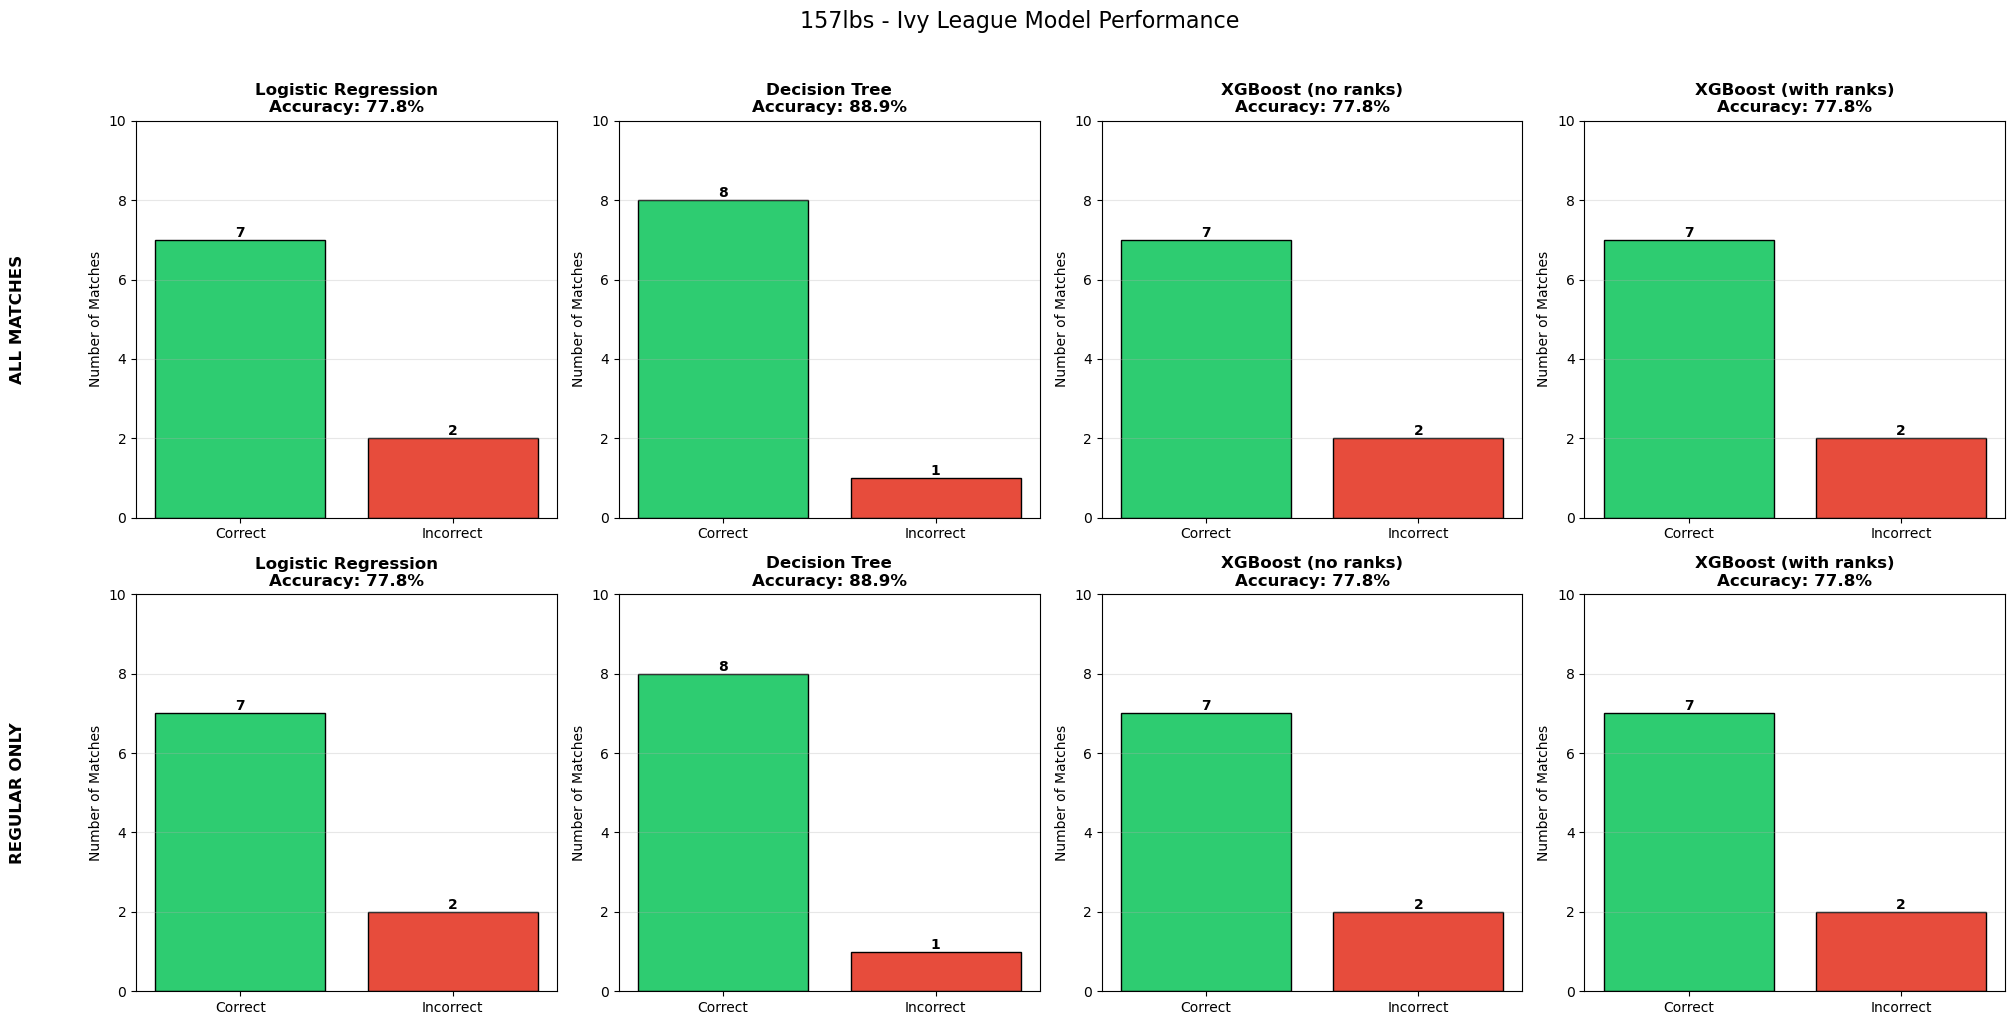


📊 MODEL RANKING - 157lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,Decision Tree,88.9%,8/9
1,Logistic Regression,77.8%,7/9
2,XGBoost (no ranks),77.8%,7/9
3,XGBoost (with ranks),77.8%,7/9



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,Decision Tree,88.9%,8/9
1,Logistic Regression,77.8%,7/9
2,XGBoost (no ranks),77.8%,7/9
3,XGBoost (with ranks),77.8%,7/9



📊 SUMMARY STATISTICS - 157lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,157lbs
2,Total Matches,9
3,Special Matches,0 (0.0%)
4,Regular Matches,9 (100.0%)



✅ 157lbs evaluation complete and added to overall results

📊 157lbs Quick Results:
   Logistic Regression: 7/9 (77.8%)
   Decision Tree: 8/9 (88.9%)
   XGBoost (no ranks): 7/9 (77.8%)
   XGBoost (with ranks): 7/9 (77.8%)

⚠️ UPSET ANALYSIS:
   Meyer Shapiro (Cornell) lost to Jude Swisher (Pennsylvania) in finals
   Shapiro had TF in semis (20-2), Swisher had 4-0 dec in semis



In [8]:
# ============================================
# 157lbs IVY LEAGUE RESULTS
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 157lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)

# Wrestlers in 157lbs:
# - Jude Swisher (Pennsylvania)
# - Meyer Shapiro (Cornell)
# - Kai Owen (Columbia)
# - Jimmy Harrington (Harvard)
# - Ethan Mojena (Brown)
# - Rocco Camillaci (Princeton)

actual_results_157 = {
    # Quarterfinals
    ('Kai Owen', 'Ethan Mojena', 'Quarterfinal'): 'Kai Owen',  # Fall 4:58
    ('Jimmy Harrington', 'Rocco Camillaci', 'Quarterfinal'): 'Jimmy Harrington',  # Dec 5-4
    # Note: Jude Swisher and Meyer Shapiro had byes - no matches to record
    
    # Semifinals
    ('Meyer Shapiro', 'Kai Owen', 'Semifinal'): 'Meyer Shapiro',  # TF 20-2 (4:46)
    ('Jude Swisher', 'Jimmy Harrington', 'Semifinal'): 'Jude Swisher',  # Dec 4-0
    
    # Consolation Semis
    ('Jimmy Harrington', 'Ethan Mojena', 'Consolation Semi'): 'Jimmy Harrington',  # Dec 4-1
    ('Kai Owen', 'Rocco Camillaci', 'Consolation Semi'): 'Kai Owen',  # Dec 9-3
    
    # 3rd Place Match
    ('Kai Owen', 'Jimmy Harrington', '3rd Place'): 'Kai Owen',  # Dec 4-0
    
    # 5th Place Match
    ('Ethan Mojena', 'Rocco Camillaci', '5th Place'): 'Ethan Mojena',  # Dec 3-2
    
    # Championship Final - UPSET!
    ('Jude Swisher', 'Meyer Shapiro', 'Championship'): 'Jude Swisher',  # Dec 8-3
}

# Track special matches (injury, forfeit, DQ) - none for 157lbs
special_matches_157 = []  # No special matches mentioned

print(f"\n📊 157lbs Results Summary:")
print(f"   Total matches: {len(actual_results_157)}")
print(f"   Special matches: {len(special_matches_157)}")
print(f"   Note: 2 byes in quarterfinals (Jude Swisher, Meyer Shapiro)")
print(f"   ⚠️ UPSET ALERT: #1 seed Meyer Shapiro lost in finals to Jude Swisher!")

# Display actual matches
actual_matches_df_157 = []
for (w1, w2, round_name), winner in actual_results_157.items():
    is_special = (w1, w2, round_name) in special_matches_157 or (w2, w1, round_name) in special_matches_157
    actual_matches_df_157.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_157 = pd.DataFrame(actual_matches_df_157)
actual_matches_df_157['Round Order'] = actual_matches_df_157['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_157 = actual_matches_df_157.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_157)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_157.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_157.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings
print("\n🔍 Checking for potential multiple meetings:")
# Kai Owen vs Jimmy Harrington - they meet in 3rd Place only? 
# Let's trace their paths:
# - Kai Owen lost in semis to Shapiro, then beat Camillaci in consi-semis
# - Jimmy Harrington lost in semis to Swisher, then beat Mojena in consi-semis
# - They meet in 3rd Place (only once)

# Jimmy Harrington vs Ethan Mojena - they meet in Consolation Semi only
# Kai Owen vs Rocco Camillaci - they meet in Consolation Semi only
# No multiple meetings in this weight class

potential_multiples = [
    ('Kai Owen', 'Jimmy Harrington'),
    ('Jimmy Harrington', 'Ethan Mojena'),
    ('Kai Owen', 'Rocco Camillaci'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_157.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# Let's also check if any wrestlers met twice in the tournament
print("\n🔍 Analyzing tournament path for potential multiple meetings:")
# Create a dictionary of each wrestler's path
wrestlers_157 = ['Jude Swisher', 'Meyer Shapiro', 'Kai Owen', 'Jimmy Harrington', 'Ethan Mojena', 'Rocco Camillaci']
paths = {}

for wrestler in wrestlers_157:
    wrestler_matches = []
    for (w1, w2, round_name), winner in actual_results_157.items():
        if wrestler in [w1, w2]:
            opponent = w2 if wrestler == w1 else w1
            result = 'Won' if winner == wrestler else 'Lost'
            wrestler_matches.append(f"{round_name}: {result} vs {opponent}")
    paths[wrestler] = wrestler_matches

# Display paths
for wrestler, matches in paths.items():
    if matches:
        print(f"\n   {wrestler}:")
        for match in matches:
            print(f"      {match}")

print("\n✅ No multiple meetings detected - each pair wrestles only once")

# ============================================
# EVALUATE 157lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 157lbs")
print("="*100)

eval_157, summary_157 = evaluate_weight_class_ivy(
    weight_class=157,
    actual_results=actual_results_157,
    special_matches=special_matches_157,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_157:
    all_weight_results.append(summary_157)
    print("\n✅ 157lbs evaluation complete and added to overall results")
    
    print("\n📊 157lbs Quick Results:")
    for model, metrics in summary_157['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
    
    # Highlight the upset
    print("\n⚠️ UPSET ANALYSIS:")
    print(f"   Meyer Shapiro (Cornell) lost to Jude Swisher (Pennsylvania) in finals")
    print(f"   Shapiro had TF in semis (20-2), Swisher had 4-0 dec in semis")
else:
    print("\n⚠️ 157lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 165lbs IVY LEAGUE TOURNAMENT RESULTS

📊 165lbs Results Summary:
   Total matches: 9
   Special matches: 0
   Note: 2 byes in quarterfinals (Cesar Alvan, Ty Whalen)


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Joseph Cangro,Maximus Norman,Joseph Cangro,REGULAR
1,Quarterfinal,Benny Rogers,Sean Seefeldt,Benny Rogers,REGULAR
2,Semifinal,Cesar Alvan,Joseph Cangro,Cesar Alvan,REGULAR
3,Semifinal,Ty Whalen,Benny Rogers,Ty Whalen,REGULAR
4,Consolation Semi,Maximus Norman,Benny Rogers,Maximus Norman,REGULAR
5,Consolation Semi,Sean Seefeldt,Joseph Cangro,Sean Seefeldt,REGULAR
6,3rd Place,Sean Seefeldt,Maximus Norman,Sean Seefeldt,REGULAR
7,5th Place,Benny Rogers,Joseph Cangro,Benny Rogers,REGULAR
8,Championship,Cesar Alvan,Ty Whalen,Cesar Alvan,REGULAR



✅ No multiple meetings detected

🔍 Checking for potential multiple meetings:
ℹ️ Joseph Cangro vs Maximus Norman - 1 match (Quarterfinal)
ℹ️ Benny Rogers vs Sean Seefeldt - 1 match (Quarterfinal)
ℹ️ Benny Rogers vs Joseph Cangro - 1 match (5th Place)
ℹ️ Maximus Norman vs Benny Rogers - 1 match (Consolation Semi)
ℹ️ Sean Seefeldt vs Joseph Cangro - 1 match (Consolation Semi)
ℹ️ Cesar Alvan vs Ty Whalen - 1 match (Championship)

🔍 Tournament path analysis:

   Cesar Alvan:
      Semifinal: Won vs Joseph Cangro
      Championship: Won vs Ty Whalen

   Ty Whalen:
      Semifinal: Won vs Benny Rogers
      Championship: Lost vs Cesar Alvan

   Joseph Cangro:
      Quarterfinal: Won vs Maximus Norman
      Semifinal: Lost vs Cesar Alvan
      Consolation Semi: Lost vs Sean Seefeldt
      5th Place: Lost vs Benny Rogers

   Benny Rogers:
      Quarterfinal: Won vs Sean Seefeldt
      Semifinal: Lost vs Ty Whalen
      Consolation Semi: Lost vs Maximus Norman
      5th Place: Won vs Joseph Can

,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Joseph Cangro,Maximus Norman,Joseph Cangro,❌,50.6%,❌,61.1%,❌,60.7%,✅,57.6%
1,Quarterfinal,Benny Rogers,Sean Seefeldt,Benny Rogers,❌,64.6%,❌,74.6%,❌,64.5%,❌,58.5%
2,Semifinal,Cesar Alvan,Joseph Cangro,Cesar Alvan,✅,66.7%,✅,74.6%,✅,65.8%,✅,83.8%
3,Semifinal,Ty Whalen,Benny Rogers,Ty Whalen,✅,65.3%,✅,74.6%,✅,80.4%,✅,80.3%
4,Consolation Semi,Maximus Norman,Benny Rogers,Maximus Norman,✅,52.0%,✅,61.1%,✅,68.9%,❌,78.0%
5,Consolation Semi,Sean Seefeldt,Joseph Cangro,Sean Seefeldt,✅,63.3%,✅,74.6%,✅,66.8%,✅,86.5%
6,3rd Place,Sean Seefeldt,Maximus Norman,Sean Seefeldt,✅,62.9%,✅,74.6%,✅,66.5%,✅,91.0%
7,5th Place,Benny Rogers,Joseph Cangro,Benny Rogers,❌,51.2%,❌,74.7%,❌,59.7%,✅,75.5%
8,Championship,Cesar Alvan,Ty Whalen,Cesar Alvan,✅,53.2%,❌,53.1%,✅,51.6%,✅,80.1%



📊 MODEL ACCURACY METRICS - 165lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,6/9,66.7%
1,Decision Tree,5/9,55.6%
2,XGBoost (no ranks),6/9,66.7%
3,XGBoost (with ranks),7/9,77.8%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,6/9,66.7%
1,Decision Tree,5/9,55.6%
2,XGBoost (no ranks),6/9,66.7%
3,XGBoost (with ranks),7/9,77.8%


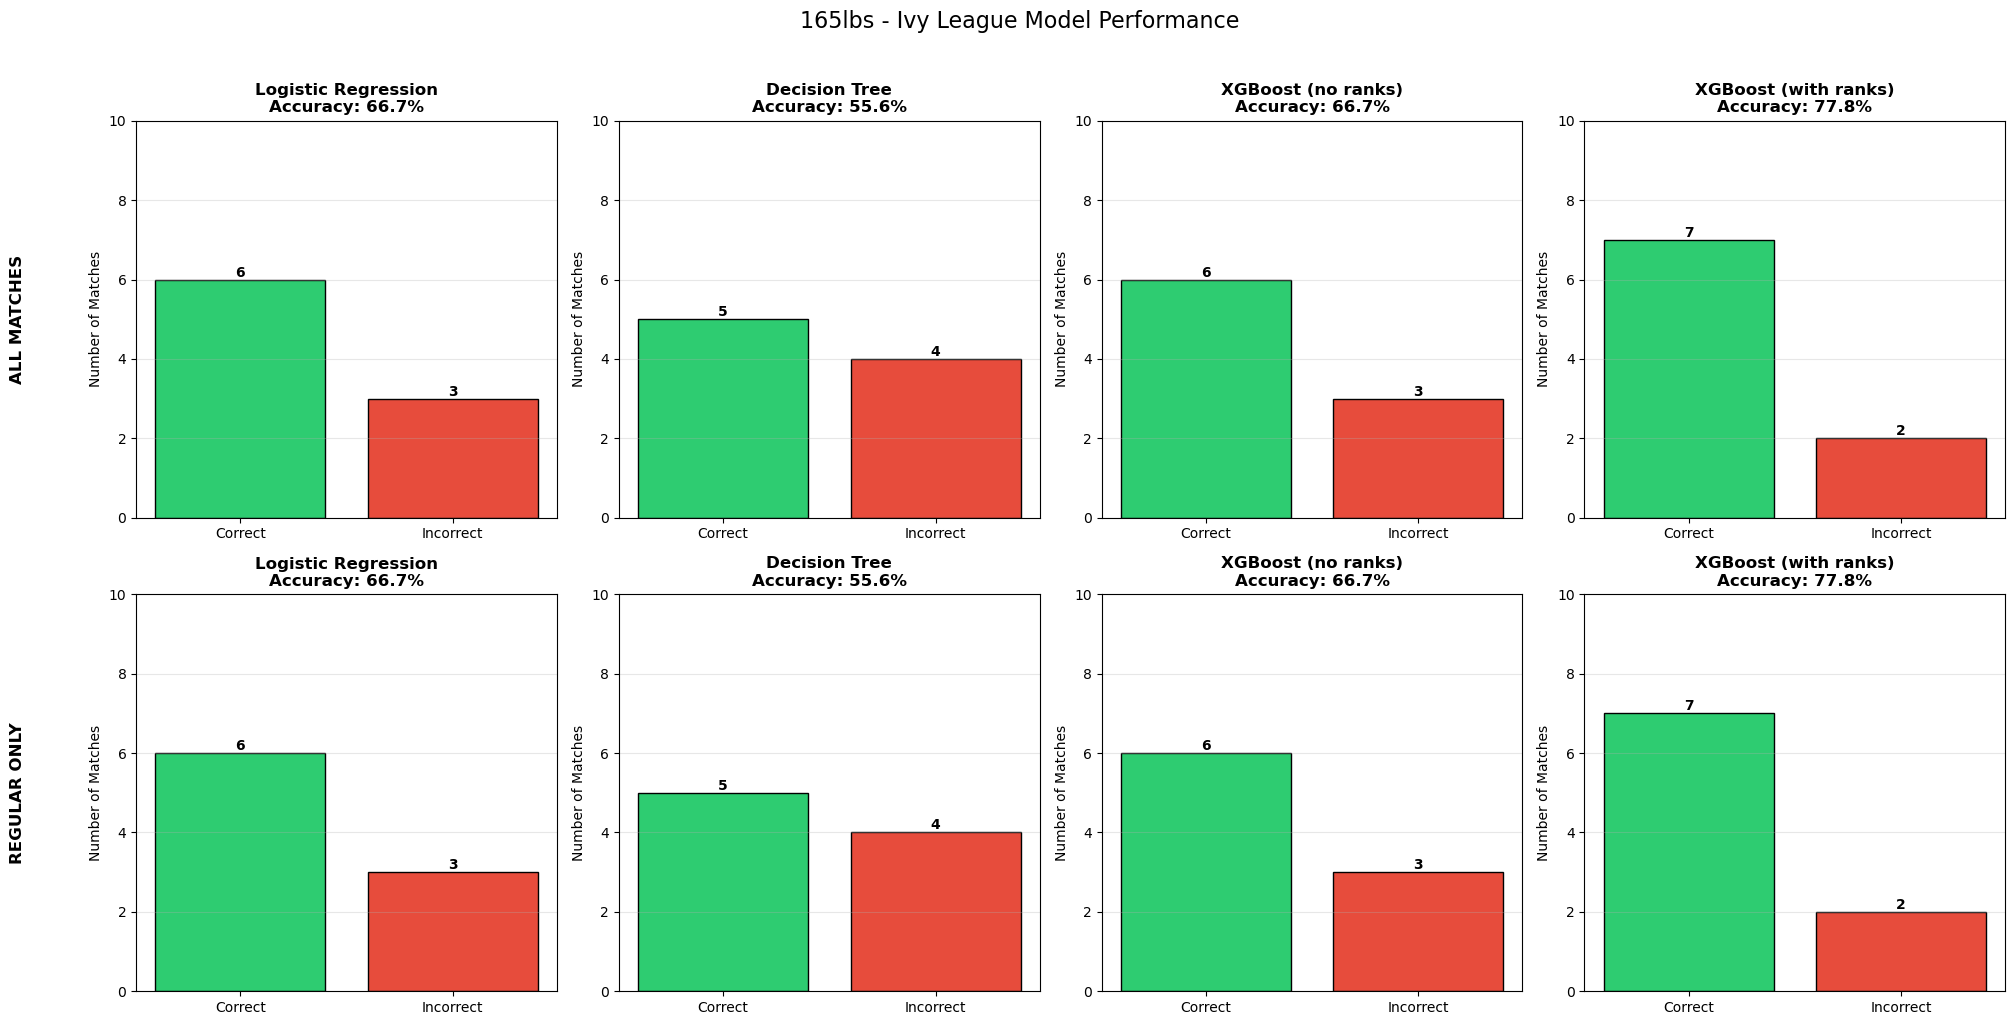


📊 MODEL RANKING - 165lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,XGBoost (with ranks),77.8%,7/9
1,Logistic Regression,66.7%,6/9
2,XGBoost (no ranks),66.7%,6/9
3,Decision Tree,55.6%,5/9



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,XGBoost (with ranks),77.8%,7/9
1,Logistic Regression,66.7%,6/9
2,XGBoost (no ranks),66.7%,6/9
3,Decision Tree,55.6%,5/9



📊 SUMMARY STATISTICS - 165lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,165lbs
2,Total Matches,9
3,Special Matches,0 (0.0%)
4,Regular Matches,9 (100.0%)



✅ 165lbs evaluation complete and added to overall results

📊 165lbs Quick Results:
   Logistic Regression: 6/9 (66.7%)
   Decision Tree: 5/9 (55.6%)
   XGBoost (no ranks): 6/9 (66.7%)
   XGBoost (with ranks): 7/9 (77.8%)



In [9]:
# ============================================
# 165lbs IVY LEAGUE RESULTS
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 165lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)

# Wrestlers in 165lbs:
# - Cesar Alvan (Columbia)
# - Ty Whalen (Princeton)
# - Joseph Cangro (Harvard)
# - Benny Rogers (Cornell)
# - Maximus Norman (Brown)
# - Sean Seefeldt (Pennsylvania)

actual_results_165 = {
    # Quarterfinals
    ('Joseph Cangro', 'Maximus Norman', 'Quarterfinal'): 'Joseph Cangro',  # Dec 5-4
    ('Benny Rogers', 'Sean Seefeldt', 'Quarterfinal'): 'Benny Rogers',  # SV Dec
    # Note: Cesar Alvan and Ty Whalen had byes - no matches to record
    
    # Semifinals
    ('Cesar Alvan', 'Joseph Cangro', 'Semifinal'): 'Cesar Alvan',  # Dec 7-6
    ('Ty Whalen', 'Benny Rogers', 'Semifinal'): 'Ty Whalen',  # Dec 7-6
    
    # Consolation Semis
    ('Maximus Norman', 'Benny Rogers', 'Consolation Semi'): 'Maximus Norman',  # Fall 4:15
    ('Sean Seefeldt', 'Joseph Cangro', 'Consolation Semi'): 'Sean Seefeldt',  # Dec 5-0
    
    # 3rd Place Match
    ('Sean Seefeldt', 'Maximus Norman', '3rd Place'): 'Sean Seefeldt',  # Dec 2-1
    
    # 5th Place Match
    ('Benny Rogers', 'Joseph Cangro', '5th Place'): 'Benny Rogers',  # Dec 11-4
    
    # Championship Final
    ('Cesar Alvan', 'Ty Whalen', 'Championship'): 'Cesar Alvan',  # SV Dec 8-1
}

# Track special matches (injury, forfeit, DQ) - none for 165lbs
special_matches_165 = []  # No special matches mentioned

print(f"\n📊 165lbs Results Summary:")
print(f"   Total matches: {len(actual_results_165)}")
print(f"   Special matches: {len(special_matches_165)}")
print(f"   Note: 2 byes in quarterfinals (Cesar Alvan, Ty Whalen)")

# Display actual matches
actual_matches_df_165 = []
for (w1, w2, round_name), winner in actual_results_165.items():
    is_special = (w1, w2, round_name) in special_matches_165 or (w2, w1, round_name) in special_matches_165
    actual_matches_df_165.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_165 = pd.DataFrame(actual_matches_df_165)
actual_matches_df_165['Round Order'] = actual_matches_df_165['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_165 = actual_matches_df_165.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_165)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_165.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_165.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings
print("\n🔍 Checking for potential multiple meetings:")
# Joseph Cangro vs Maximus Norman - they meet in Quarterfinal only
# Benny Rogers vs Sean Seefeldt - they meet in Quarterfinal only
# Joseph Cangro vs Benny Rogers - they meet in 5th Place only
# Maximus Norman vs Benny Rogers - they meet in Consolation Semi only
# Joseph Cangro vs Sean Seefeldt - they meet in Consolation Semi only
# No multiple meetings in this weight class

potential_multiples = [
    ('Joseph Cangro', 'Maximus Norman'),
    ('Benny Rogers', 'Sean Seefeldt'),
    ('Benny Rogers', 'Joseph Cangro'),
    ('Maximus Norman', 'Benny Rogers'),
    ('Sean Seefeldt', 'Joseph Cangro'),
    ('Cesar Alvan', 'Ty Whalen'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_165.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# Let's track each wrestler's path through the tournament
print("\n🔍 Tournament path analysis:")
wrestlers_165 = ['Cesar Alvan', 'Ty Whalen', 'Joseph Cangro', 'Benny Rogers', 'Maximus Norman', 'Sean Seefeldt']
paths = {}

for wrestler in wrestlers_165:
    wrestler_matches = []
    for (w1, w2, round_name), winner in actual_results_165.items():
        if wrestler in [w1, w2]:
            opponent = w2 if wrestler == w1 else w1
            result = 'Won' if winner == wrestler else 'Lost'
            wrestler_matches.append(f"{round_name}: {result} vs {opponent}")
    if wrestler_matches:
        paths[wrestler] = wrestler_matches

# Display paths
for wrestler, matches in paths.items():
    print(f"\n   {wrestler}:")
    for match in matches:
        print(f"      {match}")

# ============================================
# EVALUATE 165lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 165lbs")
print("="*100)

eval_165, summary_165 = evaluate_weight_class_ivy(
    weight_class=165,
    actual_results=actual_results_165,
    special_matches=special_matches_165,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_165:
    all_weight_results.append(summary_165)
    print("\n✅ 165lbs evaluation complete and added to overall results")
    
    print("\n📊 165lbs Quick Results:")
    for model, metrics in summary_165['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 165lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 174lbs IVY LEAGUE TOURNAMENT RESULTS

📊 174lbs Results Summary:
   Total matches: 9
   Special matches: 0
   Note: 2 byes in quarterfinals (Simon Ruiz, Nick Fine)


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Caden Bellis,Haden Bottiglieri,Caden Bellis,REGULAR
1,Quarterfinal,Holden Garcia,Drew Clearie,Holden Garcia,REGULAR
2,Semifinal,Simon Ruiz,Caden Bellis,Simon Ruiz,REGULAR
3,Semifinal,Nick Fine,Holden Garcia,Nick Fine,REGULAR
4,Consolation Semi,Holden Garcia,Haden Bottiglieri,Holden Garcia,REGULAR
5,Consolation Semi,Drew Clearie,Caden Bellis,Drew Clearie,REGULAR
6,3rd Place,Holden Garcia,Drew Clearie,Holden Garcia,REGULAR
7,5th Place,Caden Bellis,Haden Bottiglieri,Caden Bellis,REGULAR
8,Championship,Simon Ruiz,Nick Fine,Simon Ruiz,REGULAR



⚠️ Multiple meetings detected:
   Caden Bellis vs Haden Bottiglieri: 2 matches
      Rounds:
        - Quarterfinal: Caden Bellis wins
        - 5th Place: Caden Bellis wins
   Drew Clearie vs Holden Garcia: 2 matches
      Rounds:
        - Quarterfinal: Holden Garcia wins
        - 3rd Place: Holden Garcia wins

🔍 Checking for potential multiple meetings:
✅ Found: Caden Bellis vs Haden Bottiglieri - 2 matches
   - Quarterfinal: Caden Bellis wins
   - 5th Place: Caden Bellis wins
✅ Found: Holden Garcia vs Drew Clearie - 2 matches
   - Quarterfinal: Holden Garcia wins
   - 3rd Place: Holden Garcia wins
ℹ️ Holden Garcia vs Haden Bottiglieri - 1 match (Consolation Semi)
ℹ️ Drew Clearie vs Caden Bellis - 1 match (Consolation Semi)

📊 Detailed multiple meetings breakdown:

   Caden Bellis vs Haden Bottiglieri:
      Match 1: Quarterfinal - Caden Bellis wins
      Match 2: 5th Place - Caden Bellis wins

   Drew Clearie vs Holden Garcia:
      Match 1: Quarterfinal - Holden Garcia wins
    

,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Caden Bellis,Haden Bottiglieri,Caden Bellis,✅,55.7%,❌,53.1%,❌,50.5%,✅,80.1%
1,Quarterfinal,Holden Garcia,Drew Clearie,Holden Garcia,✅,59.6%,✅,61.1%,✅,65.8%,✅,88.2%
2,Semifinal,Simon Ruiz,Caden Bellis,Simon Ruiz,✅,75.0%,✅,89.0%,✅,88.4%,✅,93.8%
3,Semifinal,Nick Fine,Holden Garcia,Nick Fine,✅,57.4%,✅,61.1%,✅,64.9%,✅,71.9%
4,Consolation Semi,Holden Garcia,Haden Bottiglieri,Holden Garcia,✅,62.8%,✅,74.6%,✅,74.1%,✅,85.8%
5,Consolation Semi,Drew Clearie,Caden Bellis,Drew Clearie,❌,52.3%,❌,61.1%,✅,56.5%,❌,78.8%
6,3rd Place,Holden Garcia,Drew Clearie,Holden Garcia,✅,59.6%,✅,61.1%,✅,65.8%,✅,88.2%
7,5th Place,Caden Bellis,Haden Bottiglieri,Caden Bellis,✅,55.7%,❌,53.1%,❌,50.5%,✅,80.1%
8,Championship,Simon Ruiz,Nick Fine,Simon Ruiz,✅,62.1%,✅,53.1%,❌,53.9%,❌,55.0%



📊 MODEL ACCURACY METRICS - 174lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,8/9,88.9%
1,Decision Tree,6/9,66.7%
2,XGBoost (no ranks),6/9,66.7%
3,XGBoost (with ranks),7/9,77.8%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,8/9,88.9%
1,Decision Tree,6/9,66.7%
2,XGBoost (no ranks),6/9,66.7%
3,XGBoost (with ranks),7/9,77.8%


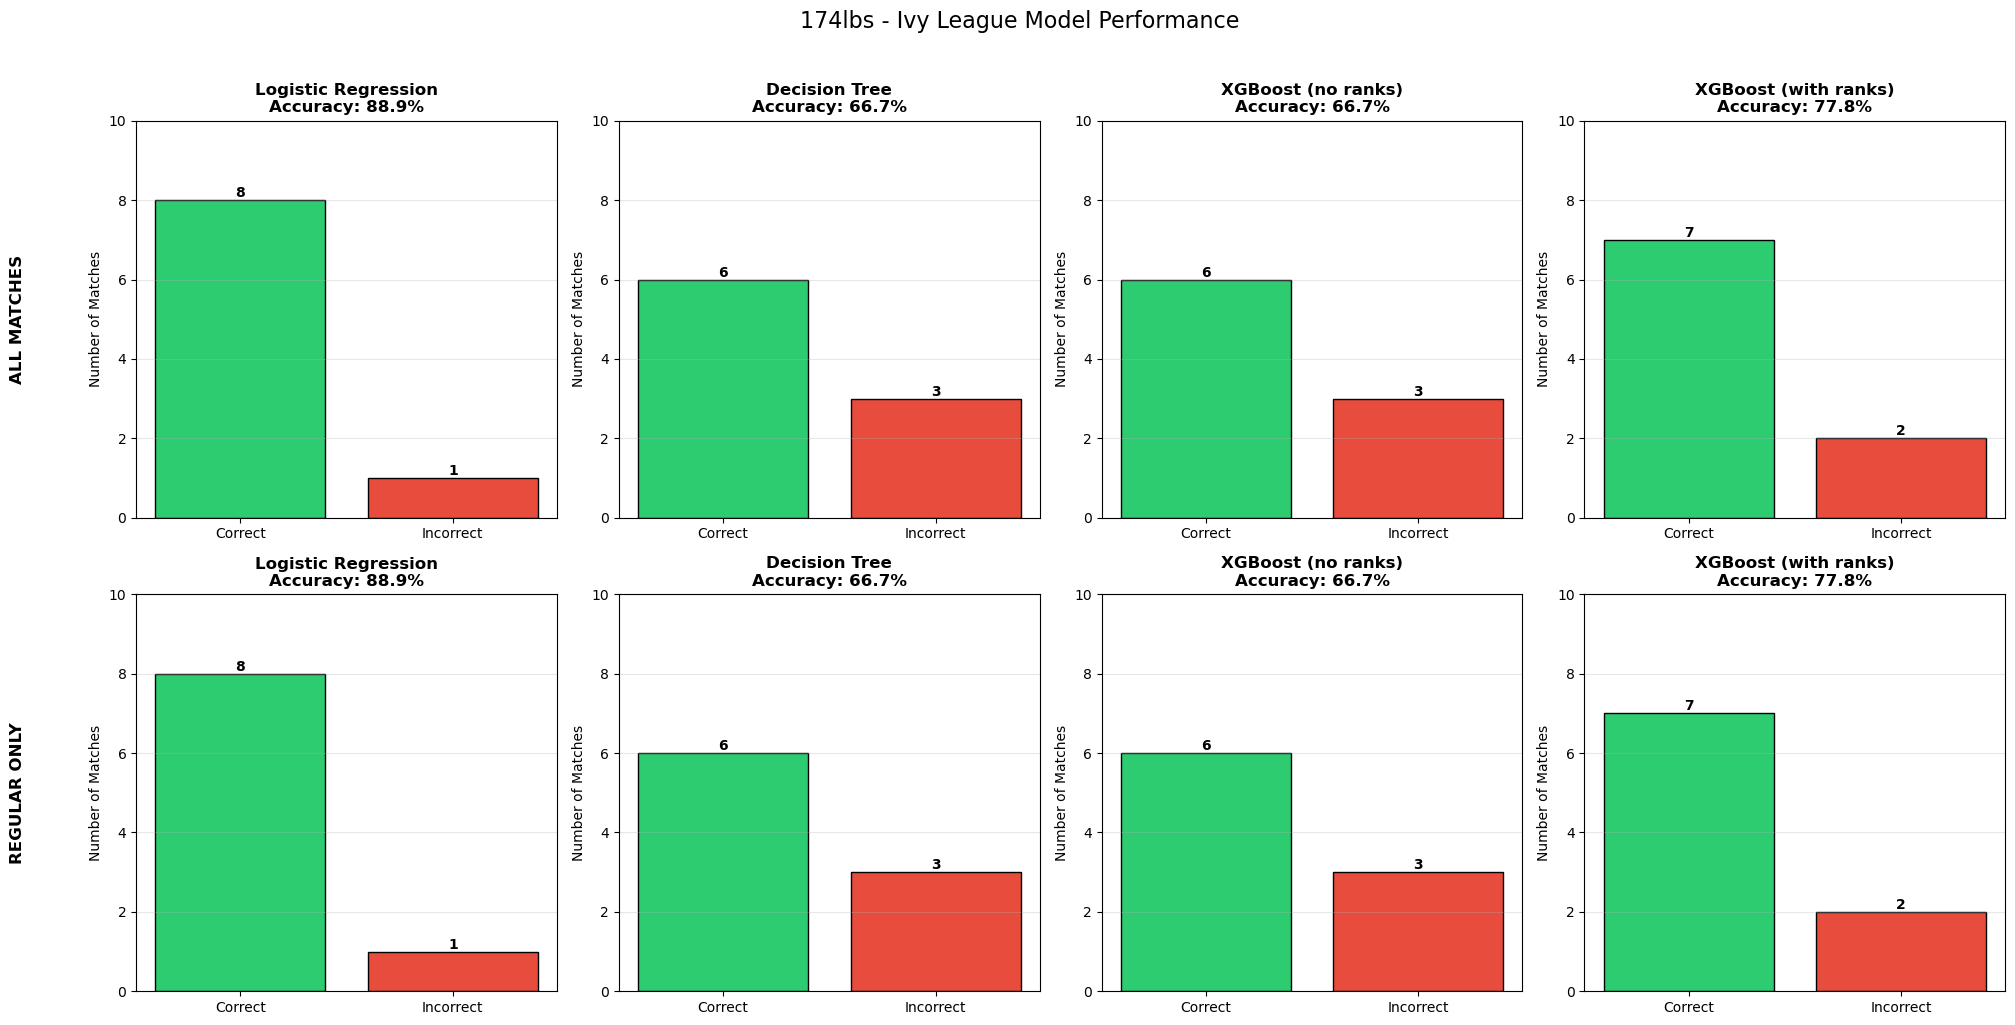


📊 MODEL RANKING - 174lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,Logistic Regression,88.9%,8/9
1,XGBoost (with ranks),77.8%,7/9
2,Decision Tree,66.7%,6/9
3,XGBoost (no ranks),66.7%,6/9



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,Logistic Regression,88.9%,8/9
1,XGBoost (with ranks),77.8%,7/9
2,Decision Tree,66.7%,6/9
3,XGBoost (no ranks),66.7%,6/9



📊 SUMMARY STATISTICS - 174lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,174lbs
2,Total Matches,9
3,Special Matches,0 (0.0%)
4,Regular Matches,9 (100.0%)



✅ 174lbs evaluation complete and added to overall results

📊 174lbs Quick Results:
   Logistic Regression: 8/9 (88.9%)
   Decision Tree: 6/9 (66.7%)
   XGBoost (no ranks): 6/9 (66.7%)
   XGBoost (with ranks): 7/9 (77.8%)



In [10]:
# ============================================
# 174lbs IVY LEAGUE RESULTS
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 174lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)

# Wrestlers in 174lbs:
# - Simon Ruiz (Cornell)
# - Nick Fine (Columbia)
# - Caden Bellis (Pennsylvania)
# - Holden Garcia (Princeton)
# - Drew Clearie (Brown)
# - Haden Bottiglieri (Harvard)

actual_results_174 = {
    # Quarterfinals
    ('Caden Bellis', 'Haden Bottiglieri', 'Quarterfinal'): 'Caden Bellis',  # Dec 6-4
    ('Holden Garcia', 'Drew Clearie', 'Quarterfinal'): 'Holden Garcia',  # MD 14-4
    # Note: Simon Ruiz and Nick Fine had byes - no matches to record
    
    # Semifinals
    ('Simon Ruiz', 'Caden Bellis', 'Semifinal'): 'Simon Ruiz',  # TF 18-2 (5:50)
    ('Nick Fine', 'Holden Garcia', 'Semifinal'): 'Nick Fine',  # Dec 5-1
    
    # Consolation Semis
    ('Holden Garcia', 'Haden Bottiglieri', 'Consolation Semi'): 'Holden Garcia',  # Dec 9-4
    ('Drew Clearie', 'Caden Bellis', 'Consolation Semi'): 'Drew Clearie',  # Dec 9-4
    
    # 3rd Place Match
    ('Holden Garcia', 'Drew Clearie', '3rd Place'): 'Holden Garcia',  # Dec 8-2
    
    # 5th Place Match
    ('Caden Bellis', 'Haden Bottiglieri', '5th Place'): 'Caden Bellis',  # Dec 6-3
    
    # Championship Final
    ('Simon Ruiz', 'Nick Fine', 'Championship'): 'Simon Ruiz',  # Dec 8-2
}

# Track special matches (injury, forfeit, DQ) - none for 174lbs
special_matches_174 = []  # No special matches mentioned

print(f"\n📊 174lbs Results Summary:")
print(f"   Total matches: {len(actual_results_174)}")
print(f"   Special matches: {len(special_matches_174)}")
print(f"   Note: 2 byes in quarterfinals (Simon Ruiz, Nick Fine)")

# Display actual matches
actual_matches_df_174 = []
for (w1, w2, round_name), winner in actual_results_174.items():
    is_special = (w1, w2, round_name) in special_matches_174 or (w2, w1, round_name) in special_matches_174
    actual_matches_df_174.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_174 = pd.DataFrame(actual_matches_df_174)
actual_matches_df_174['Round Order'] = actual_matches_df_174['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_174 = actual_matches_df_174.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_174)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_174.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_174.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings
print("\n🔍 Checking for potential multiple meetings:")
# Caden Bellis vs Haden Bottiglieri - they meet in Quarterfinal and 5th Place?
# Let's trace:
# - Quarterfinal: Caden Bellis beat Haden Bottiglieri (6-4)
# - 5th Place: Caden Bellis beat Haden Bottiglieri (6-3)
# This IS a multiple meeting! They wrestle twice with same outcome (both Bellis wins)

# Holden Garcia vs Drew Clearie - they meet in Quarterfinal and 3rd Place?
# - Quarterfinal: Holden Garcia beat Drew Clearie (MD 14-4)
# - 3rd Place: Holden Garcia beat Drew Clearie (8-2)
# This IS a multiple meeting! They wrestle twice with same outcome (both Garcia wins)

# Holden Garcia vs Haden Bottiglieri - they meet in Consolation Semi only
# Drew Clearie vs Caden Bellis - they meet in Consolation Semi only

potential_multiples = [
    ('Caden Bellis', 'Haden Bottiglieri'),
    ('Holden Garcia', 'Drew Clearie'),
    ('Holden Garcia', 'Haden Bottiglieri'),
    ('Drew Clearie', 'Caden Bellis'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_174.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# If multiple meetings found, show detailed breakdown
if multiple_meetings:
    print("\n📊 Detailed multiple meetings breakdown:")
    for matchup in multiple_meetings:
        print(f"\n   {matchup}:")
        w1, w2 = matchup.split(' vs ')
        matches = [(r, win) for (a, b, r), win in actual_results_174.items() 
                   if (a == w1 and b == w2) or (a == w2 and b == w1)]
        for i, (round_name, winner) in enumerate(matches, 1):
            print(f"      Match {i}: {round_name} - {winner} wins")

# Let's track each wrestler's path through the tournament
print("\n🔍 Tournament path analysis:")
wrestlers_174 = ['Simon Ruiz', 'Nick Fine', 'Caden Bellis', 'Holden Garcia', 'Drew Clearie', 'Haden Bottiglieri']
paths = {}

for wrestler in wrestlers_174:
    wrestler_matches = []
    for (w1, w2, round_name), winner in actual_results_174.items():
        if wrestler in [w1, w2]:
            opponent = w2 if wrestler == w1 else w1
            result = 'Won' if winner == wrestler else 'Lost'
            wrestler_matches.append(f"{round_name}: {result} vs {opponent}")
    if wrestler_matches:
        paths[wrestler] = wrestler_matches

# Display paths
for wrestler, matches in paths.items():
    print(f"\n   {wrestler}:")
    for match in matches:
        print(f"      {match}")

# ============================================
# EVALUATE 174lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 174lbs")
print("="*100)

eval_174, summary_174 = evaluate_weight_class_ivy(
    weight_class=174,
    actual_results=actual_results_174,
    special_matches=special_matches_174,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_174:
    all_weight_results.append(summary_174)
    print("\n✅ 174lbs evaluation complete and added to overall results")
    
    print("\n📊 174lbs Quick Results:")
    for model, metrics in summary_174['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 174lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 184lbs IVY LEAGUE TOURNAMENT RESULTS

📊 184lbs Results Summary:
   Total matches: 9
   Special matches: 1
   Note: 2 byes in quarterfinals (Joe Curtis, Louis Cerchio)
   ⚠️ 3rd Place match ended by injury default


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Matthew Walsh,Xavier Giles,Matthew Walsh,REGULAR
1,Quarterfinal,Liam Carlin,Connor O'Donnell,Liam Carlin,REGULAR
2,Semifinal,Joe Curtis,Matthew Walsh,Joe Curtis,REGULAR
3,Semifinal,Louis Cerchio,Liam Carlin,Louis Cerchio,REGULAR
4,Consolation Semi,Liam Carlin,Xavier Giles,Liam Carlin,REGULAR
5,Consolation Semi,Matthew Walsh,Connor O'Donnell,Matthew Walsh,REGULAR
6,3rd Place,Liam Carlin,Matthew Walsh,Liam Carlin,SPECIAL
7,5th Place,Xavier Giles,Connor O'Donnell,Xavier Giles,REGULAR
8,Championship,Joe Curtis,Louis Cerchio,Joe Curtis,REGULAR



✅ No multiple meetings detected

🔍 Checking for potential multiple meetings:
ℹ️ Liam Carlin vs Matthew Walsh - 1 match (3rd Place)
ℹ️ Matthew Walsh vs Xavier Giles - 1 match (Quarterfinal)
ℹ️ Liam Carlin vs Connor O'Donnell - 1 match (Quarterfinal)
ℹ️ Xavier Giles vs Connor O'Donnell - 1 match (5th Place)
ℹ️ Joe Curtis vs Louis Cerchio - 1 match (Championship)

🔍 Tournament path analysis:

   Joe Curtis:
      Semifinal: Won vs Matthew Walsh
      Championship: Won vs Louis Cerchio

   Louis Cerchio:
      Semifinal: Won vs Liam Carlin
      Championship: Lost vs Joe Curtis

   Matthew Walsh:
      Quarterfinal: Won vs Xavier Giles
      Semifinal: Lost vs Joe Curtis
      Consolation Semi: Won vs Connor O'Donnell
      3rd Place: Lost (INJURY DEFAULT) vs Liam Carlin

   Liam Carlin:
      Quarterfinal: Won vs Connor O'Donnell
      Semifinal: Lost vs Louis Cerchio
      Consolation Semi: Won vs Xavier Giles
      3rd Place: Won (INJURY DEFAULT) vs Matthew Walsh

   Xavier Giles:
    

,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Matthew Walsh,Xavier Giles,Matthew Walsh,✅,57.5%,✅,53.1%,✅,67.8%,❌,57.9%
1,Quarterfinal,Liam Carlin,Connor O'Donnell,Liam Carlin,✅,66.9%,✅,74.6%,✅,75.0%,✅,93.3%
2,Semifinal,Joe Curtis,Matthew Walsh,Joe Curtis,✅,75.0%,✅,89.0%,✅,78.4%,✅,83.8%
3,Semifinal,Louis Cerchio,Liam Carlin,Louis Cerchio,❌,51.3%,✅,61.1%,✅,72.2%,✅,85.6%
4,Consolation Semi,Liam Carlin,Xavier Giles,Liam Carlin,✅,54.2%,✅,61.1%,✅,54.6%,✅,52.0%
5,Consolation Semi,Matthew Walsh,Connor O'Donnell,Matthew Walsh,✅,70.2%,✅,74.6%,✅,86.0%,✅,93.0%
6,3rd Place,Liam Carlin,Matthew Walsh,Liam Carlin,❌,53.6%,❌,74.7%,❌,67.8%,✅,76.3%
7,5th Place,Xavier Giles,Connor O'Donnell,Xavier Giles,✅,63.3%,✅,74.6%,✅,75.0%,✅,94.3%
8,Championship,Joe Curtis,Louis Cerchio,Joe Curtis,✅,78.9%,✅,89.0%,✅,80.0%,✅,63.3%



📊 MODEL ACCURACY METRICS - 184lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,7/9,77.8%
1,Decision Tree,8/9,88.9%
2,XGBoost (no ranks),8/9,88.9%
3,XGBoost (with ranks),8/9,88.9%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,7/8,87.5%
1,Decision Tree,8/8,100.0%
2,XGBoost (no ranks),8/8,100.0%
3,XGBoost (with ranks),7/8,87.5%


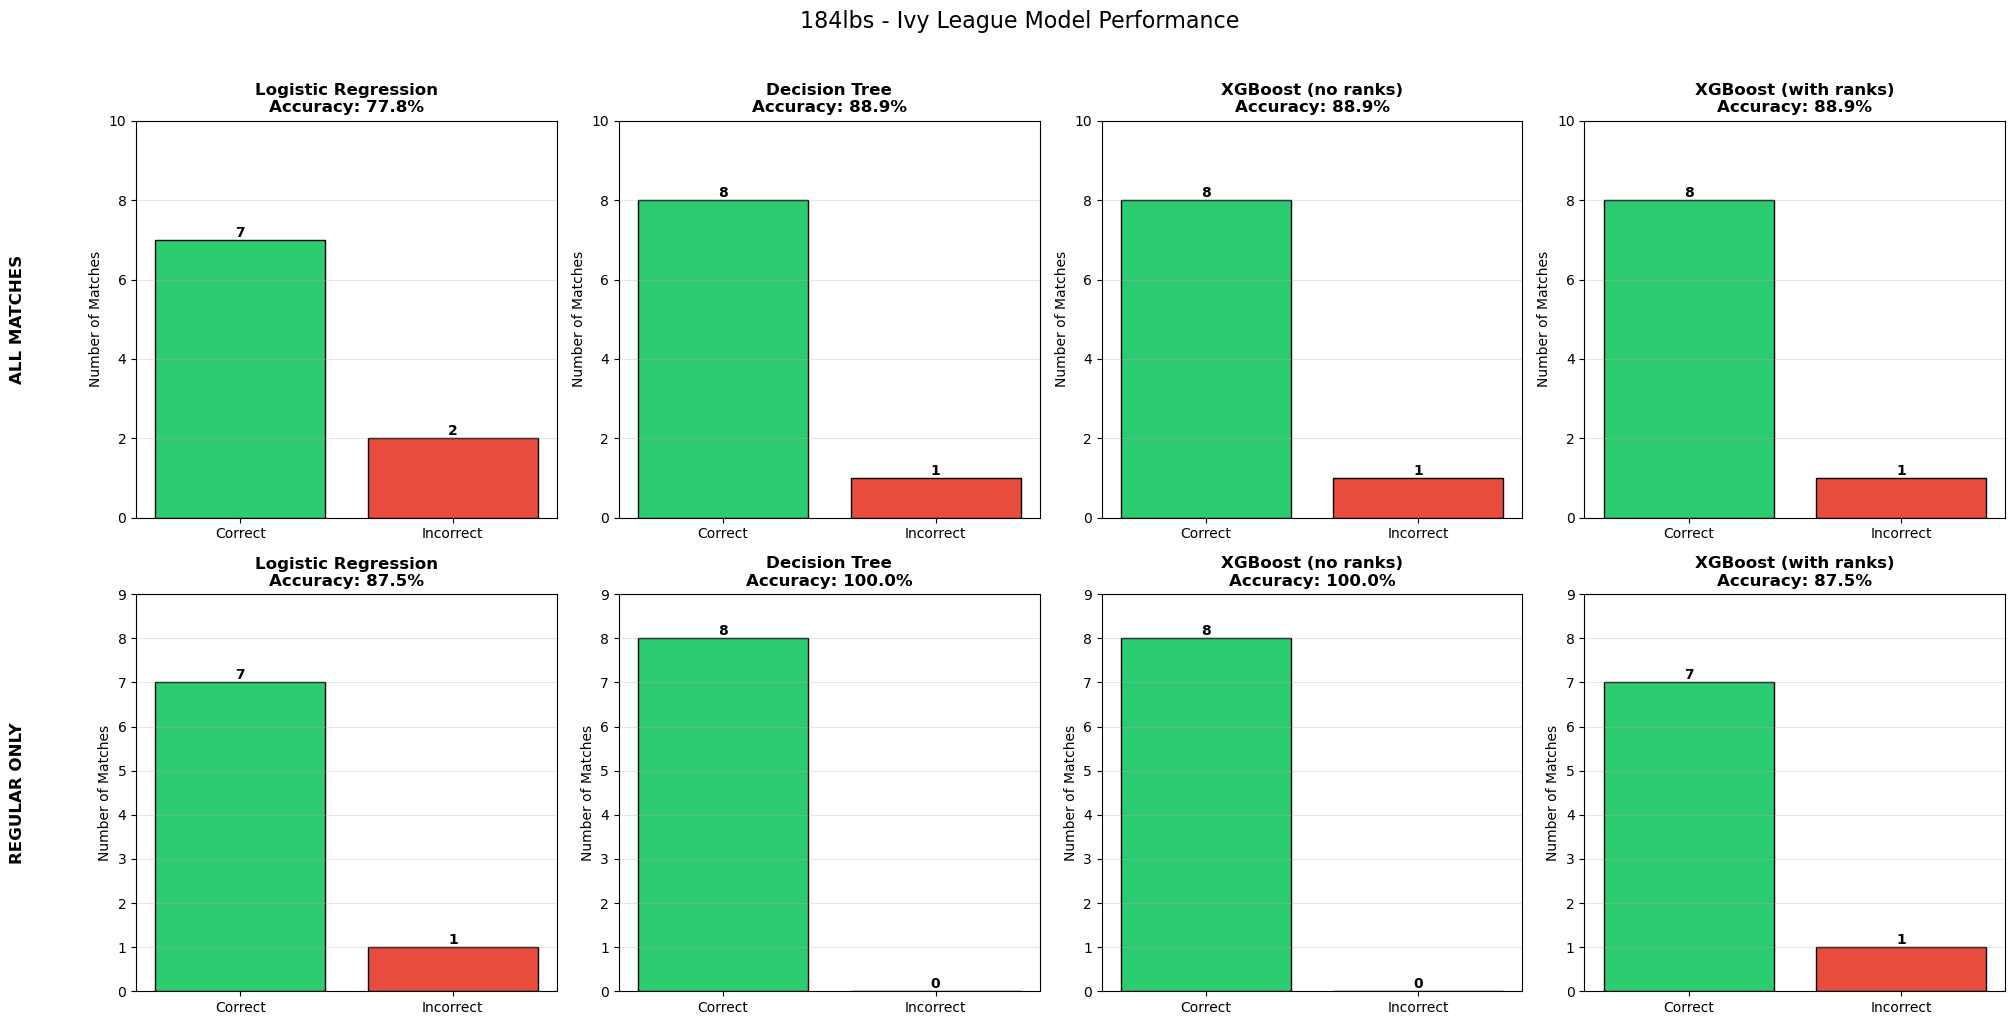


📊 MODEL RANKING - 184lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,Decision Tree,88.9%,8/9
1,XGBoost (no ranks),88.9%,8/9
2,XGBoost (with ranks),88.9%,8/9
3,Logistic Regression,77.8%,7/9



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,Decision Tree,100.0%,8/8
1,XGBoost (no ranks),100.0%,8/8
2,Logistic Regression,87.5%,7/8
3,XGBoost (with ranks),87.5%,7/8



📊 SUMMARY STATISTICS - 184lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,184lbs
2,Total Matches,9
3,Special Matches,1 (11.1%)
4,Regular Matches,8 (88.9%)



✅ 184lbs evaluation complete and added to overall results

📊 184lbs Quick Results:
   Logistic Regression: 7/8 (87.5%)
   Decision Tree: 8/8 (100.0%)
   XGBoost (no ranks): 8/8 (100.0%)
   XGBoost (with ranks): 7/8 (87.5%)

⚠️ Special matches in this weight class: 1
   - 3rd Place: Liam Carlin vs Matthew Walsh (Injury Default)



In [11]:
# ============================================
# 184lbs IVY LEAGUE RESULTS
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 184lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)

# Wrestlers in 184lbs:
# - Joe Curtis (Columbia)
# - Louis Cerchio (Cornell)
# - Matthew Walsh (Harvard)
# - Liam Carlin (Pennsylvania)
# - Xavier Giles (Princeton)
# - Connor O'Donnell (Brown)

actual_results_184 = {
    # Quarterfinals
    ('Matthew Walsh', 'Xavier Giles', 'Quarterfinal'): 'Matthew Walsh',  # Dec 4-2
    ('Liam Carlin', 'Connor O\'Donnell', 'Quarterfinal'): 'Liam Carlin',  # Dec 11-8
    # Note: Joe Curtis and Louis Cerchio had byes - no matches to record
    
    # Semifinals
    ('Joe Curtis', 'Matthew Walsh', 'Semifinal'): 'Joe Curtis',  # Dec 3-0
    ('Louis Cerchio', 'Liam Carlin', 'Semifinal'): 'Louis Cerchio',  # MD 12-3
    
    # Consolation Semis
    ('Liam Carlin', 'Xavier Giles', 'Consolation Semi'): 'Liam Carlin',  # Dec 4-1
    ('Matthew Walsh', 'Connor O\'Donnell', 'Consolation Semi'): 'Matthew Walsh',  # Dec 8-1
    
    # 3rd Place Match - INJURY DEFAULT
    ('Liam Carlin', 'Matthew Walsh', '3rd Place'): 'Liam Carlin',  # Injury default
    
    # 5th Place Match
    ('Xavier Giles', 'Connor O\'Donnell', '5th Place'): 'Xavier Giles',  # Dec 10-8
    
    # Championship Final
    ('Joe Curtis', 'Louis Cerchio', 'Championship'): 'Joe Curtis',  # Dec 7-1
}

# Track special matches (injury, forfeit, DQ)
special_matches_184 = [
    ('Liam Carlin', 'Matthew Walsh', '3rd Place'),  # Injury default
]

print(f"\n📊 184lbs Results Summary:")
print(f"   Total matches: {len(actual_results_184)}")
print(f"   Special matches: {len(special_matches_184)}")
print(f"   Note: 2 byes in quarterfinals (Joe Curtis, Louis Cerchio)")
print(f"   ⚠️ 3rd Place match ended by injury default")

# Display actual matches
actual_matches_df_184 = []
for (w1, w2, round_name), winner in actual_results_184.items():
    is_special = (w1, w2, round_name) in special_matches_184 or (w2, w1, round_name) in special_matches_184
    actual_matches_df_184.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_184 = pd.DataFrame(actual_matches_df_184)
actual_matches_df_184['Round Order'] = actual_matches_df_184['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_184 = actual_matches_df_184.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_184)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_184.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_184.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings
print("\n🔍 Checking for potential multiple meetings:")
# Liam Carlin vs Matthew Walsh - they meet in Semifinal and 3rd Place?
# Let's trace:
# - Semifinal: Louis Cerchio beat Liam Carlin, Joe Curtis beat Matthew Walsh
# - They don't meet in semis, but they DO meet in 3rd Place (injury default)
# So they meet ONCE in 3rd Place only

# Matthew Walsh vs Xavier Giles - they meet in Quarterfinal only
# Liam Carlin vs Connor O'Donnell - they meet in Quarterfinal only
# Xavier Giles vs Connor O'Donnell - they meet in 5th Place only
# No multiple meetings in this weight class

potential_multiples = [
    ('Liam Carlin', 'Matthew Walsh'),
    ('Matthew Walsh', 'Xavier Giles'),
    ('Liam Carlin', 'Connor O\'Donnell'),
    ('Xavier Giles', 'Connor O\'Donnell'),
    ('Joe Curtis', 'Louis Cerchio'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_184.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# Let's track each wrestler's path through the tournament
print("\n🔍 Tournament path analysis:")
wrestlers_184 = ['Joe Curtis', 'Louis Cerchio', 'Matthew Walsh', 'Liam Carlin', 'Xavier Giles', 'Connor O\'Donnell']
paths = {}

for wrestler in wrestlers_184:
    wrestler_matches = []
    for (w1, w2, round_name), winner in actual_results_184.items():
        if wrestler in [w1, w2]:
            opponent = w2 if wrestler == w1 else w1
            result = 'Won' if winner == wrestler else 'Lost'
            # Mark special matches
            is_special = (w1, w2, round_name) in special_matches_184 or (w2, w1, round_name) in special_matches_184
            special_marker = " (INJURY DEFAULT)" if is_special else ""
            wrestler_matches.append(f"{round_name}: {result}{special_marker} vs {opponent}")
    if wrestler_matches:
        paths[wrestler] = wrestler_matches

# Display paths
for wrestler, matches in paths.items():
    print(f"\n   {wrestler}:")
    for match in matches:
        print(f"      {match}")

# ============================================
# EVALUATE 184lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 184lbs")
print("="*100)

eval_184, summary_184 = evaluate_weight_class_ivy(
    weight_class=184,
    actual_results=actual_results_184,
    special_matches=special_matches_184,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_184:
    all_weight_results.append(summary_184)
    print("\n✅ 184lbs evaluation complete and added to overall results")
    
    print("\n📊 184lbs Quick Results:")
    if 'regular_metrics' in summary_184 and summary_184['regular_metrics']:
        for model, metrics in summary_184['regular_metrics'].items():
            print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
    
    # Show special matches info
    print(f"\n⚠️ Special matches in this weight class: {len(special_matches_184)}")
    for (w1, w2, round_name) in special_matches_184:
        print(f"   - {round_name}: {w1} vs {w2} (Injury Default)")
else:
    print("\n⚠️ 184lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 197lbs IVY LEAGUE TOURNAMENT RESULTS

📊 197lbs Results Summary:
   Total matches: 9
   Special matches: 0
   Note: 2 byes in quarterfinals (Andrew Reall, Jack Wehmeyer)


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Aiden Hanning,Hudson Skove,Aiden Hanning,REGULAR
1,Quarterfinal,Martin Cosgrove,Conor McCloskey,Martin Cosgrove,REGULAR
2,Semifinal,Andrew Reall,Aiden Hanning,Andrew Reall,REGULAR
3,Semifinal,Jack Wehmeyer,Martin Cosgrove,Jack Wehmeyer,REGULAR
4,Consolation Semi,Martin Cosgrove,Hudson Skove,Martin Cosgrove,REGULAR
5,Consolation Semi,Aiden Hanning,Conor McCloskey,Aiden Hanning,REGULAR
6,3rd Place,Martin Cosgrove,Aiden Hanning,Martin Cosgrove,REGULAR
7,5th Place,Hudson Skove,Conor McCloskey,Hudson Skove,REGULAR
8,Championship,Andrew Reall,Jack Wehmeyer,Andrew Reall,REGULAR



✅ No multiple meetings detected

🔍 Checking for potential multiple meetings:
ℹ️ Martin Cosgrove vs Aiden Hanning - 1 match (3rd Place)
ℹ️ Aiden Hanning vs Hudson Skove - 1 match (Quarterfinal)
ℹ️ Martin Cosgrove vs Conor McCloskey - 1 match (Quarterfinal)
ℹ️ Martin Cosgrove vs Hudson Skove - 1 match (Consolation Semi)
ℹ️ Aiden Hanning vs Conor McCloskey - 1 match (Consolation Semi)
ℹ️ Hudson Skove vs Conor McCloskey - 1 match (5th Place)
ℹ️ Andrew Reall vs Jack Wehmeyer - 1 match (Championship)

🔍 Tournament path analysis:

   Andrew Reall:
      Semifinal: Won vs Aiden Hanning
      Championship: Won vs Jack Wehmeyer

   Jack Wehmeyer:
      Semifinal: Won vs Martin Cosgrove
      Championship: Lost vs Andrew Reall

   Aiden Hanning:
      Quarterfinal: Won vs Hudson Skove
      Semifinal: Lost vs Andrew Reall
      Consolation Semi: Won vs Conor McCloskey
      3rd Place: Lost vs Martin Cosgrove

   Martin Cosgrove:
      Quarterfinal: Won vs Conor McCloskey
      Semifinal: Lost vs

,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Aiden Hanning,Hudson Skove,Aiden Hanning,❌,59.2%,✅,61.1%,✅,53.0%,✅,81.3%
1,Quarterfinal,Martin Cosgrove,Conor McCloskey,Martin Cosgrove,✅,69.1%,✅,74.6%,✅,83.5%,✅,87.8%
2,Semifinal,Andrew Reall,Aiden Hanning,Andrew Reall,✅,85.0%,✅,89.0%,✅,89.9%,✅,78.6%
3,Semifinal,Jack Wehmeyer,Martin Cosgrove,Jack Wehmeyer,✅,69.0%,✅,74.6%,✅,81.4%,✅,70.8%
4,Consolation Semi,Martin Cosgrove,Hudson Skove,Martin Cosgrove,✅,53.7%,✅,61.1%,✅,75.2%,✅,87.8%
5,Consolation Semi,Aiden Hanning,Conor McCloskey,Aiden Hanning,✅,57.0%,✅,61.1%,✅,60.0%,✅,71.5%
6,3rd Place,Martin Cosgrove,Aiden Hanning,Martin Cosgrove,✅,63.0%,✅,74.6%,✅,68.2%,❌,54.5%
7,5th Place,Hudson Skove,Conor McCloskey,Hudson Skove,✅,66.0%,✅,74.6%,✅,70.2%,❌,63.3%
8,Championship,Andrew Reall,Jack Wehmeyer,Andrew Reall,✅,60.0%,✅,53.1%,✅,53.2%,❌,83.8%



📊 MODEL ACCURACY METRICS - 197lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,8/9,88.9%
1,Decision Tree,9/9,100.0%
2,XGBoost (no ranks),9/9,100.0%
3,XGBoost (with ranks),6/9,66.7%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,8/9,88.9%
1,Decision Tree,9/9,100.0%
2,XGBoost (no ranks),9/9,100.0%
3,XGBoost (with ranks),6/9,66.7%


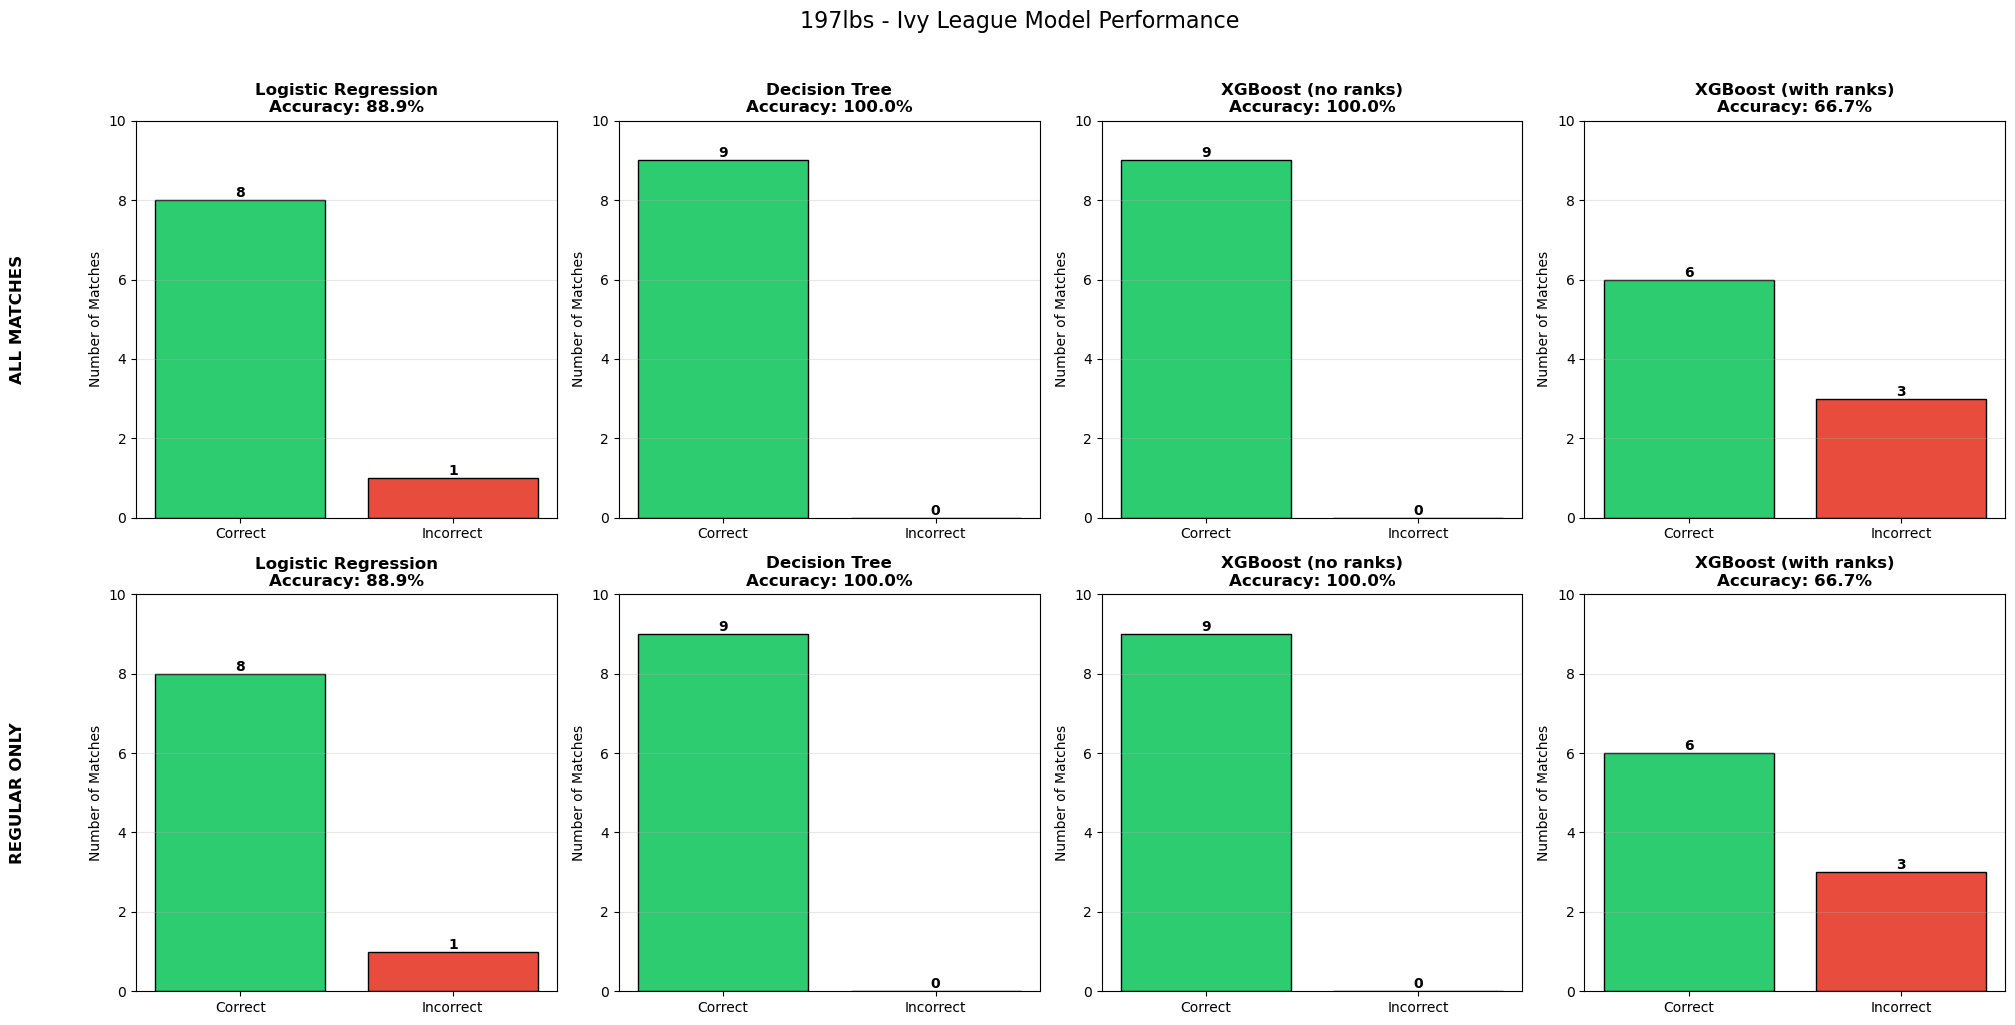


📊 MODEL RANKING - 197lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,Decision Tree,100.0%,9/9
1,XGBoost (no ranks),100.0%,9/9
2,Logistic Regression,88.9%,8/9
3,XGBoost (with ranks),66.7%,6/9



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,Decision Tree,100.0%,9/9
1,XGBoost (no ranks),100.0%,9/9
2,Logistic Regression,88.9%,8/9
3,XGBoost (with ranks),66.7%,6/9



📊 SUMMARY STATISTICS - 197lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,197lbs
2,Total Matches,9
3,Special Matches,0 (0.0%)
4,Regular Matches,9 (100.0%)



✅ 197lbs evaluation complete and added to overall results

📊 197lbs Quick Results:
   Logistic Regression: 8/9 (88.9%)
   Decision Tree: 9/9 (100.0%)
   XGBoost (no ranks): 9/9 (100.0%)
   XGBoost (with ranks): 6/9 (66.7%)



In [12]:
# ============================================
# 197lbs IVY LEAGUE RESULTS
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 197lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)

# Wrestlers in 197lbs:
# - Andrew Reall (Brown)
# - Jack Wehmeyer (Columbia)
# - Aiden Hanning (Cornell)
# - Martin Cosgrove (Pennsylvania)
# - Hudson Skove (Harvard)
# - Conor McCloskey (Princeton)

actual_results_197 = {
    # Quarterfinals
    ('Aiden Hanning', 'Hudson Skove', 'Quarterfinal'): 'Aiden Hanning',  # Dec 10-3
    ('Martin Cosgrove', 'Conor McCloskey', 'Quarterfinal'): 'Martin Cosgrove',  # MD 16-2
    # Note: Andrew Reall and Jack Wehmeyer had byes - no matches to record
    
    # Semifinals
    ('Andrew Reall', 'Aiden Hanning', 'Semifinal'): 'Andrew Reall',  # MD 10-2
    ('Jack Wehmeyer', 'Martin Cosgrove', 'Semifinal'): 'Jack Wehmeyer',  # Dec 4-2
    
    # Consolation Semis
    ('Martin Cosgrove', 'Hudson Skove', 'Consolation Semi'): 'Martin Cosgrove',  # Fall 4:33
    ('Aiden Hanning', 'Conor McCloskey', 'Consolation Semi'): 'Aiden Hanning',  # MD 16-3
    
    # 3rd Place Match
    ('Martin Cosgrove', 'Aiden Hanning', '3rd Place'): 'Martin Cosgrove',  # Dec 7-4
    
    # 5th Place Match
    ('Hudson Skove', 'Conor McCloskey', '5th Place'): 'Hudson Skove',  # Dec 4-0
    
    # Championship Final
    ('Andrew Reall', 'Jack Wehmeyer', 'Championship'): 'Andrew Reall',  # Dec SV 4-1
}

# Track special matches (injury, forfeit, DQ) - none for 197lbs
special_matches_197 = []  # No special matches mentioned

print(f"\n📊 197lbs Results Summary:")
print(f"   Total matches: {len(actual_results_197)}")
print(f"   Special matches: {len(special_matches_197)}")
print(f"   Note: 2 byes in quarterfinals (Andrew Reall, Jack Wehmeyer)")

# Display actual matches
actual_matches_df_197 = []
for (w1, w2, round_name), winner in actual_results_197.items():
    is_special = (w1, w2, round_name) in special_matches_197 or (w2, w1, round_name) in special_matches_197
    actual_matches_df_197.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_197 = pd.DataFrame(actual_matches_df_197)
actual_matches_df_197['Round Order'] = actual_matches_df_197['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_197 = actual_matches_df_197.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_197)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_197.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_197.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings
print("\n🔍 Checking for potential multiple meetings:")
# Martin Cosgrove vs Aiden Hanning - they meet in Semifinal and 3rd Place?
# Let's trace:
# - Semifinal: Jack Wehmeyer beat Martin Cosgrove, Andrew Reall beat Aiden Hanning
# - So they DON'T meet in semis, but they DO meet in 3rd Place
# - They meet ONCE in 3rd Place only

# Aiden Hanning vs Hudson Skove - they meet in Quarterfinal only
# Martin Cosgrove vs Conor McCloskey - they meet in Quarterfinal only
# Martin Cosgrove vs Hudson Skove - they meet in Consolation Semi only
# Aiden Hanning vs Conor McCloskey - they meet in Consolation Semi only
# Hudson Skove vs Conor McCloskey - they meet in 5th Place only
# No multiple meetings in this weight class

potential_multiples = [
    ('Martin Cosgrove', 'Aiden Hanning'),
    ('Aiden Hanning', 'Hudson Skove'),
    ('Martin Cosgrove', 'Conor McCloskey'),
    ('Martin Cosgrove', 'Hudson Skove'),
    ('Aiden Hanning', 'Conor McCloskey'),
    ('Hudson Skove', 'Conor McCloskey'),
    ('Andrew Reall', 'Jack Wehmeyer'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_197.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# Let's track each wrestler's path through the tournament
print("\n🔍 Tournament path analysis:")
wrestlers_197 = ['Andrew Reall', 'Jack Wehmeyer', 'Aiden Hanning', 'Martin Cosgrove', 'Hudson Skove', 'Conor McCloskey']
paths = {}

for wrestler in wrestlers_197:
    wrestler_matches = []
    for (w1, w2, round_name), winner in actual_results_197.items():
        if wrestler in [w1, w2]:
            opponent = w2 if wrestler == w1 else w1
            result = 'Won' if winner == wrestler else 'Lost'
            wrestler_matches.append(f"{round_name}: {result} vs {opponent}")
    if wrestler_matches:
        paths[wrestler] = wrestler_matches

# Display paths
for wrestler, matches in paths.items():
    print(f"\n   {wrestler}:")
    for match in matches:
        print(f"      {match}")

# Highlight the championship finish
print("\n🏆 Championship Final:")
print(f"   Andrew Reall (Brown) vs Jack Wehmeyer (Columbia)")
print(f"   Result: Andrew Reall wins 4-1 in Sudden Victory")

# ============================================
# EVALUATE 197lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 197lbs")
print("="*100)

eval_197, summary_197 = evaluate_weight_class_ivy(
    weight_class=197,
    actual_results=actual_results_197,
    special_matches=special_matches_197,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_197:
    all_weight_results.append(summary_197)
    print("\n✅ 197lbs evaluation complete and added to overall results")
    
    print("\n📊 197lbs Quick Results:")
    for model, metrics in summary_197['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 197lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 285lbs IVY LEAGUE TOURNAMENT RESULTS
⚠️ NOTE: Late roster change - Anderson Olcott substituted for Sebastian Garibaldi
   Matches involving Olcott will be marked as SPECIAL since models predicted based on Garibaldi

📊 285lbs Results Summary:
   Total matches: 9
   Special matches (due to substitution): 3
   Note: 2 byes in quarterfinals (Vincent Mueller, Alex Semenenko)
   ⚠️ Anderson Olcott substituted for Sebastian Garibaldi - all his matches marked SPECIAL


,Round,Wrestler 1,Wrestler 2,Winner,Type,Notes
0,Quarterfinal,Ashton Davis,Daniel Bittner,Ashton Davis,REGULAR,
1,Quarterfinal,John Pardo,Anderson Olcott,John Pardo,SPECIAL,Substitute for Garibaldi
2,Semifinal,Vincent Mueller,Ashton Davis,Vincent Mueller,REGULAR,
3,Semifinal,Alex Semenenko,John Pardo,Alex Semenenko,REGULAR,
4,Consolation Semi,John Pardo,Daniel Bittner,John Pardo,REGULAR,
5,Consolation Semi,Ashton Davis,Anderson Olcott,Ashton Davis,SPECIAL,Substitute for Garibaldi
6,3rd Place,Ashton Davis,John Pardo,Ashton Davis,REGULAR,
7,5th Place,Daniel Bittner,Anderson Olcott,Daniel Bittner,SPECIAL,Substitute for Garibaldi
8,Championship,Vincent Mueller,Alex Semenenko,Vincent Mueller,REGULAR,



✅ No multiple meetings detected

🔍 Checking for potential multiple meetings:
ℹ️ Ashton Davis vs John Pardo - 1 match (3rd Place: Ashton Davis)
ℹ️ John Pardo vs Daniel Bittner - 1 match (Consolation Semi: John Pardo)
ℹ️ Vincent Mueller vs Alex Semenenko - 1 match (Championship: Vincent Mueller)

🔍 Tournament path analysis:

   Vincent Mueller:
      Semifinal: Won vs Ashton Davis
      Championship: Won vs Alex Semenenko

   Alex Semenenko:
      Semifinal: Won vs John Pardo
      Championship: Lost vs Vincent Mueller

   Ashton Davis:
      Quarterfinal: Won vs Daniel Bittner
      Semifinal: Lost vs Vincent Mueller
      Consolation Semi: Won (vs SUBSTITUTE) vs Anderson Olcott
      3rd Place: Won vs John Pardo

   John Pardo:
      Quarterfinal: Won (vs SUBSTITUTE) vs Anderson Olcott
      Semifinal: Lost vs Alex Semenenko
      Consolation Semi: Won vs Daniel Bittner
      3rd Place: Lost vs Ashton Davis

   Daniel Bittner:
      Quarterfinal: Lost vs Ashton Davis
      Consolation

,Round,Wrestler 1,Wrestler 2,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Ashton Davis,Daniel Bittner,Ashton Davis,❌,67.2%,❌,57.0%,❌,54.2%,✅,79.8%
1,Semifinal,Vincent Mueller,Ashton Davis,Vincent Mueller,✅,86.1%,✅,74.6%,✅,88.4%,✅,87.6%
2,Semifinal,Alex Semenenko,John Pardo,Alex Semenenko,✅,63.3%,✅,74.6%,✅,77.1%,❌,52.0%
3,Consolation Semi,John Pardo,Daniel Bittner,John Pardo,✅,64.4%,✅,74.6%,✅,83.7%,✅,95.3%
4,3rd Place,Ashton Davis,John Pardo,Ashton Davis,❌,78.5%,❌,70.0%,❌,87.7%,❌,81.8%
5,Championship,Vincent Mueller,Alex Semenenko,Vincent Mueller,❌,50.4%,✅,61.1%,✅,55.2%,✅,92.3%



📊 MODEL ACCURACY METRICS - 285lbs

🔴 INCLUDING ALL MATCHES:


,Model,Correct,Accuracy
0,Logistic Regression,3/6,50.0%
1,Decision Tree,4/6,66.7%
2,XGBoost (no ranks),4/6,66.7%
3,XGBoost (with ranks),4/6,66.7%



🟢 REGULAR MATCHES ONLY:


,Model,Correct,Accuracy
0,Logistic Regression,3/6,50.0%
1,Decision Tree,4/6,66.7%
2,XGBoost (no ranks),4/6,66.7%
3,XGBoost (with ranks),4/6,66.7%


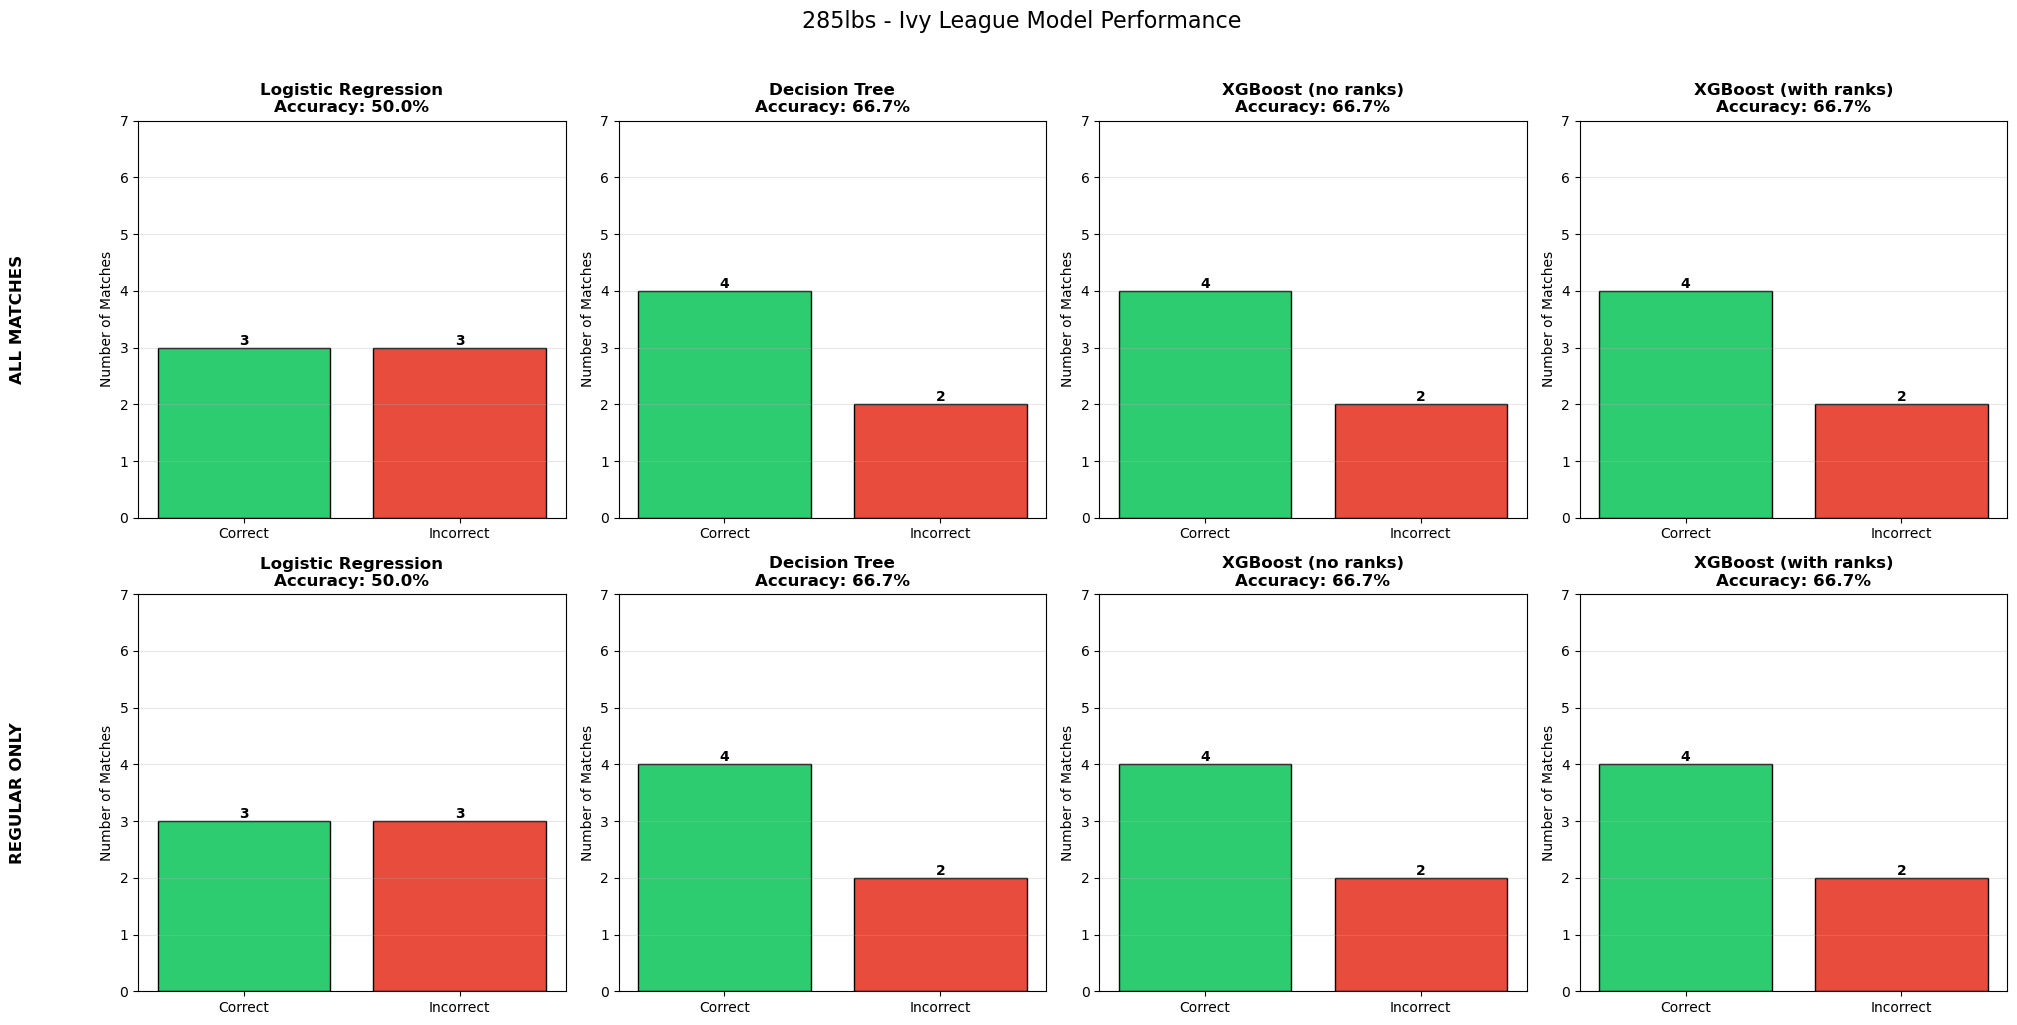


📊 MODEL RANKING - 285lbs

🏆 All Matches:


,Model,Accuracy,Correct
0,Decision Tree,66.7%,4/6
1,XGBoost (no ranks),66.7%,4/6
2,XGBoost (with ranks),66.7%,4/6
3,Logistic Regression,50.0%,3/6



🏆 Regular Matches Only:


,Model,Accuracy,Correct
0,Decision Tree,66.7%,4/6
1,XGBoost (no ranks),66.7%,4/6
2,XGBoost (with ranks),66.7%,4/6
3,Logistic Regression,50.0%,3/6



📊 SUMMARY STATISTICS - 285lbs


,Metric,Value
0,Conference,Ivy League
1,Weight Class,285lbs
2,Total Matches,6
3,Special Matches,0 (0.0%)
4,Regular Matches,6 (100.0%)



✅ 285lbs evaluation complete and added to overall results

📊 285lbs Quick Results:
   Total matches: 6
   Special matches (substitution): 0
   Regular matches: 6

   Regular matches only (excluding substitution):
      Logistic Regression: 3/6 (50.0%)
      Decision Tree: 4/6 (66.7%)
      XGBoost (no ranks): 4/6 (66.7%)
      XGBoost (with ranks): 4/6 (66.7%)

   All matches (including substitution):
      Logistic Regression: 3/6 (50.0%)
      Decision Tree: 4/6 (66.7%)
      XGBoost (no ranks): 4/6 (66.7%)
      XGBoost (with ranks): 4/6 (66.7%)



In [13]:
# ============================================
# 285lbs IVY LEAGUE RESULTS - WITH SUBSTITUTION
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 285lbs IVY LEAGUE TOURNAMENT RESULTS")
print("="*100)
print("⚠️ NOTE: Late roster change - Anderson Olcott substituted for Sebastian Garibaldi")
print("   Matches involving Olcott will be marked as SPECIAL since models predicted based on Garibaldi")

# Wrestlers in 285lbs:
# - Vincent Mueller (Columbia)
# - Alex Semenenko (Brown)
# - Ashton Davis (Cornell)
# - John Pardo (Pennsylvania)
# - Daniel Bittner (Harvard)
# - Anderson Olcott (Princeton) - SUBSTITUTE for Sebastian Garibaldi

actual_results_285 = {
    # Quarterfinals
    ('Ashton Davis', 'Daniel Bittner', 'Quarterfinal'): 'Ashton Davis',  # TF 18-3 (4:56)
    ('John Pardo', 'Anderson Olcott', 'Quarterfinal'): 'John Pardo',  # TF 19-4 (4:05) - vs substitute
    # Note: Vincent Mueller and Alex Semenenko had byes - no matches to record
    
    # Semifinals
    ('Vincent Mueller', 'Ashton Davis', 'Semifinal'): 'Vincent Mueller',  # Dec 8-1
    ('Alex Semenenko', 'John Pardo', 'Semifinal'): 'Alex Semenenko',  # Dec 4-1
    
    # Consolation Semis
    ('John Pardo', 'Daniel Bittner', 'Consolation Semi'): 'John Pardo',  # TF 24-9 (6:28)
    ('Ashton Davis', 'Anderson Olcott', 'Consolation Semi'): 'Ashton Davis',  # Fall 0:18 - vs substitute
    
    # 3rd Place Match
    ('Ashton Davis', 'John Pardo', '3rd Place'): 'Ashton Davis',  # Fall 0:58
    
    # 5th Place Match
    ('Daniel Bittner', 'Anderson Olcott', '5th Place'): 'Daniel Bittner',  # Dec 7-1 - vs substitute
    
    # Championship Final
    ('Vincent Mueller', 'Alex Semenenko', 'Championship'): 'Vincent Mueller',  # Dec 8-1
}

# Track special matches due to substitution
# Any match involving Anderson Olcott (the substitute) should be marked as SPECIAL
# because models predicted based on Sebastian Garibaldi
special_matches_285 = [
    ('John Pardo', 'Anderson Olcott', 'Quarterfinal'),
    ('Ashton Davis', 'Anderson Olcott', 'Consolation Semi'),
    ('Daniel Bittner', 'Anderson Olcott', '5th Place'),
]

print(f"\n📊 285lbs Results Summary:")
print(f"   Total matches: {len(actual_results_285)}")
print(f"   Special matches (due to substitution): {len(special_matches_285)}")
print(f"   Note: 2 byes in quarterfinals (Vincent Mueller, Alex Semenenko)")
print(f"   ⚠️ Anderson Olcott substituted for Sebastian Garibaldi - all his matches marked SPECIAL")

# Display actual matches
actual_matches_df_285 = []
for (w1, w2, round_name), winner in actual_results_285.items():
    is_special = (w1, w2, round_name) in special_matches_285 or (w2, w1, round_name) in special_matches_285
    special_reason = " (SUBSTITUTE)" if is_special else ""
    actual_matches_df_285.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR',
        'Notes': 'Substitute for Garibaldi' if is_special else ''
    })

# Sort by round order
round_order = ['Quarterfinal', 'Semifinal', 'Consolation Semi', '3rd Place', '5th Place', 'Championship']
actual_matches_df_285 = pd.DataFrame(actual_matches_df_285)
actual_matches_df_285['Round Order'] = actual_matches_df_285['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_285 = actual_matches_df_285.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_285)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_285.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_285.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                is_special = (w1, w2, round_name) in special_matches_285 or (w2, w1, round_name) in special_matches_285
                special_marker = " (SUBSTITUTE)" if is_special else ""
                print(f"        - {round_name}: {winner} wins{special_marker}")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings
print("\n🔍 Checking for potential multiple meetings:")
# Ashton Davis vs John Pardo - they meet in 3rd Place only
# John Pardo vs Daniel Bittner - they meet in Consolation Semi only
# All matches involving Olcott are with different opponents
# No multiple meetings in this weight class

potential_multiples = [
    ('Ashton Davis', 'John Pardo'),
    ('John Pardo', 'Daniel Bittner'),
    ('Vincent Mueller', 'Alex Semenenko'),
]

for w1, w2 in potential_multiples:
    matches = []
    for (a, b, r), win in actual_results_285.items():
        if (a == w1 and b == w2) or (a == w2 and b == w1):
            is_special = (a, b, r) in special_matches_285 or (b, a, r) in special_matches_285
            matches.append((r, win, is_special))
    
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner, is_special in matches:
            special_marker = " (SUBSTITUTE)" if is_special else ""
            print(f"   - {round_name}: {winner} wins{special_marker}")
    elif len(matches) == 1:
        round_name, winner, is_special = matches[0]
        special_marker = " (SUBSTITUTE)" if is_special else ""
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({round_name}: {winner}{special_marker})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# Let's track each wrestler's path through the tournament
print("\n🔍 Tournament path analysis:")
wrestlers_285 = ['Vincent Mueller', 'Alex Semenenko', 'Ashton Davis', 'John Pardo', 'Daniel Bittner', 'Anderson Olcott']
paths = {}

for wrestler in wrestlers_285:
    wrestler_matches = []
    for (w1, w2, round_name), winner in actual_results_285.items():
        if wrestler in [w1, w2]:
            opponent = w2 if wrestler == w1 else w1
            result = 'Won' if winner == wrestler else 'Lost'
            is_special = (w1, w2, round_name) in special_matches_285 or (w2, w1, round_name) in special_matches_285
            special_marker = " (vs SUBSTITUTE)" if is_special and wrestler != 'Anderson Olcott' else " (as SUBSTITUTE)" if is_special and wrestler == 'Anderson Olcott' else ""
            wrestler_matches.append(f"{round_name}: {result}{special_marker} vs {opponent}")
    if wrestler_matches:
        paths[wrestler] = wrestler_matches

# Display paths
for wrestler, matches in paths.items():
    print(f"\n   {wrestler}:")
    for match in matches:
        print(f"      {match}")

# Highlight the substitution impact
print("\n⚠️ SUBSTITUTION IMPACT:")
print(f"   Anderson Olcott substituted for Sebastian Garibaldi at the last minute")
print(f"   All {len(special_matches_285)} matches involving Olcott are marked as SPECIAL")
print(f"   Models predicted based on Garibaldi's stats, not Olcott's")
print(f"   These matches will be excluded from 'regular matches only' metrics")

# ============================================
# EVALUATE 285lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 285lbs (with substitution)")
print("="*100)

eval_285, summary_285 = evaluate_weight_class_ivy(
    weight_class=285,
    actual_results=actual_results_285,
    special_matches=special_matches_285,
    predictions_df=ivy_preds,
    conference="Ivy League",
    save_plots=False
)

if summary_285:
    all_weight_results.append(summary_285)
    print("\n✅ 285lbs evaluation complete and added to overall results")
    
    print("\n📊 285lbs Quick Results:")
    print(f"   Total matches: {summary_285['total_matches']}")
    print(f"   Special matches (substitution): {summary_285['special_matches']}")
    print(f"   Regular matches: {summary_285['regular_matches']}")
    
    if 'regular_metrics' in summary_285 and summary_285['regular_metrics']:
        print("\n   Regular matches only (excluding substitution):")
        for model, metrics in summary_285['regular_metrics'].items():
            print(f"      {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
    
    if 'all_metrics' in summary_285 and summary_285['all_metrics']:
        print("\n   All matches (including substitution):")
        for model, metrics in summary_285['all_metrics'].items():
            print(f"      {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 285lbs evaluation failed")

print("\n" + "="*100)

# Overall Statistics


📋 IVY LEAGUE CHAMPION PREDICTION RESULTS

🏆 IVY LEAGUE - CHAMPION PREDICTION ACCURACY BY WEIGHT CLASS


,Weight,Actual Champion,LOGREG,DT,XGB1,XGB2,Consensus,Correct
0,125 lbs,Marc-Anthony McGowan (Princeton),Marc-Anthony McGowan,Marc-Anthony McGowan,Marc-Anthony McGowan,Marc-Anthony McGowan,Unanimous,✅
1,133 lbs,Tyler Ferrera (Cornell),Evan Mougalian,Evan Mougalian,Evin Gursoy,Evin Gursoy,Split Decision,❌
2,141 lbs,Vince Cornella (Cornell),Vince Cornella,CJ Composto,Vince Cornella,Vince Cornella,3/4 Models,✅
3,149 lbs,Jaxon Joy (Cornell),Jaxon Joy,Jaxon Joy,Jaxon Joy,Jaxon Joy,Unanimous,✅
4,157 lbs,Jude Swisher (Pennsylvania),Meyer Shapiro,Meyer Shapiro,Meyer Shapiro,Meyer Shapiro,Unanimous,❌
5,165 lbs,Cesar Alvan (Columbia),Cesar Alvan,Ty Whalen,Cesar Alvan,Cesar Alvan,3/4 Models,✅
6,174 lbs,Simon Ruiz (Cornell),Simon Ruiz,Simon Ruiz,Nick Fine,Nick Fine,Split Decision,✅
7,184 lbs,Joe Curtis (Columbia),Joe Curtis,Joe Curtis,Joe Curtis,Joe Curtis,Unanimous,✅
8,197 lbs,Andrew Reall (Brown),Andrew Reall,Andrew Reall,Andrew Reall,Jack Wehmeyer,3/4 Models,✅
9,285 lbs,Vincent Mueller (Columbia),Alex Semenenko,Vincent Mueller,Vincent Mueller,Vincent Mueller,3/4 Models,✅



📊 IVY LEAGUE - MODEL CHAMPION PREDICTION ACCURACY


,Model,Correct Champions,Accuracy
0,LOGREG,7/10,70.0%
1,DT,6/10,60.0%
2,XGB1,7/10,70.0%
3,XGB2,6/10,60.0%



📊 Overall Champion Prediction Accuracy: 8/10 (80.0%)

📊 IVY LEAGUE - CONSENSUS BREAKDOWN


...

,Model,Correct,Total,Accuracy
1,Logistic Regression,69,87,79.3
2,XGBoost (no ranks),69,87,79.3
0,Decision Tree,68,87,78.2
3,XGBoost (with ranks),65,87,74.7



🟢 REGULAR MATCHES ONLY (Excluding Special):


,Model,Correct,Total,Accuracy
1,Logistic Regression,69,86,80.2
2,XGBoost (no ranks),69,86,80.2
0,Decision Tree,68,86,79.1
3,XGBoost (with ranks),64,86,74.4



📊 MATCHES BY WEIGHT CLASS:


,Weight,Total Matches
0,125 lbs,9
1,133 lbs,9
2,141 lbs,9
3,149 lbs,9
4,157 lbs,9
5,165 lbs,9
6,174 lbs,9
7,184 lbs,9
8,197 lbs,9
9,285 lbs,6


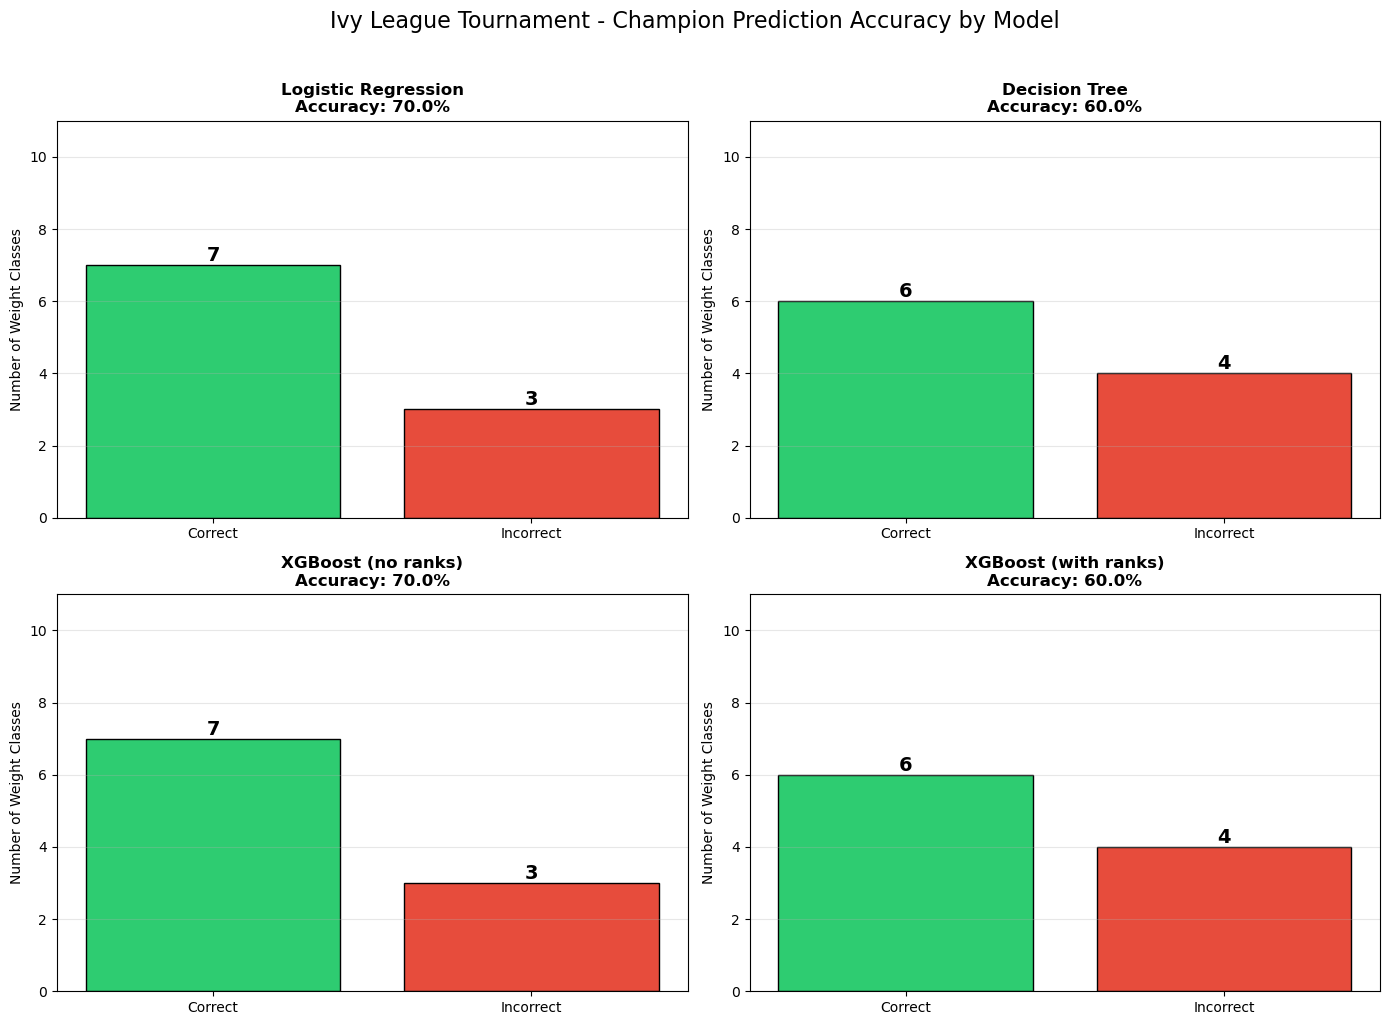

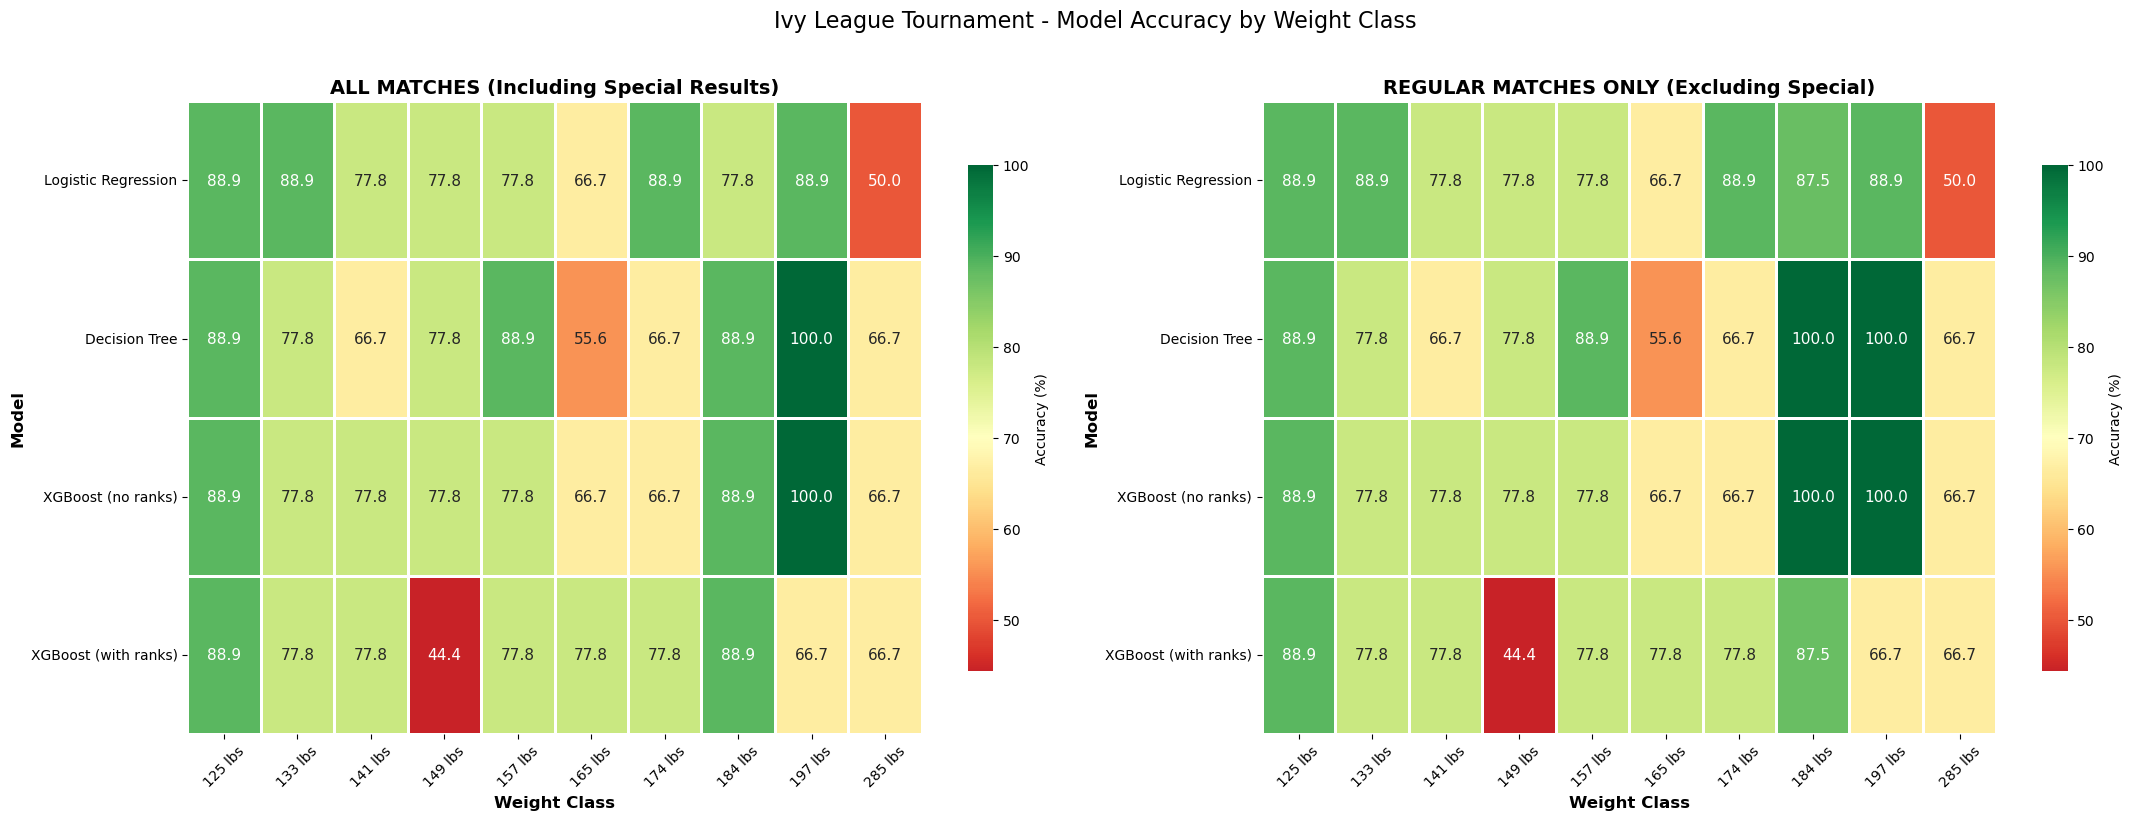


📋 COMPREHENSIVE IVY LEAGUE TOURNAMENT SUMMARY


,Weight,Actual Champion,LOGREG,DT,XGB1,XGB2,Consensus,Correct
0,125 lbs,Marc-Anthony McGowan (Princeton),Marc-Anthony McGowan,Marc-Anthony McGowan,Marc-Anthony McGowan,Marc-Anthony McGowan,Unanimous,✅
1,133 lbs,Tyler Ferrera (Cornell),Evan Mougalian,Evan Mougalian,Evin Gursoy,Evin Gursoy,Split Decision,❌
2,141 lbs,Vince Cornella (Cornell),Vince Cornella,CJ Composto,Vince Cornella,Vince Cornella,3/4 Models,✅
3,149 lbs,Jaxon Joy (Cornell),Jaxon Joy,Jaxon Joy,Jaxon Joy,Jaxon Joy,Unanimous,✅
4,157 lbs,Jude Swisher (Pennsylvania),Meyer Shapiro,Meyer Shapiro,Meyer Shapiro,Meyer Shapiro,Unanimous,❌
5,165 lbs,Cesar Alvan (Columbia),Cesar Alvan,Ty Whalen,Cesar Alvan,Cesar Alvan,3/4 Models,✅
6,174 lbs,Simon Ruiz (Cornell),Simon Ruiz,Simon Ruiz,Nick Fine,Nick Fine,Split Decision,✅
7,184 lbs,Joe Curtis (Columbia),Joe Curtis,Joe Curtis,Joe Curtis,Joe Curtis,Unanimous,✅
8,197 lbs,Andrew Reall (Brown),Andrew Reall,Andrew Reall,Andrew Reall,Jack Wehmeyer,3/4 Models,✅
9,285 lbs,Vincent Mueller (Columbia),Alex Semenenko,Vincent Mueller,Vincent Mueller,Vincent Mueller,3/4 Models,✅



✅ IVY LEAGUE ANALYSIS COMPLETE


In [17]:
# ============================================
# IVY LEAGUE - COMPLETE CHAMPION PREDICTION RESULTS (ALL 10 WEIGHTS)
# ============================================

print("\n" + "="*100)
print("📋 IVY LEAGUE CHAMPION PREDICTION RESULTS")
print("="*100)

# Actual champions from Ivy League tournament results (based on your data)
actual_champions_ivy = {
    125: {'name': 'Marc-Anthony McGowan', 'team': 'Princeton'},
    133: {'name': 'Tyler Ferrera', 'team': 'Cornell'},
    141: {'name': 'Vince Cornella', 'team': 'Cornell'},
    149: {'name': 'Jaxon Joy', 'team': 'Cornell'},
    157: {'name': 'Jude Swisher', 'team': 'Pennsylvania'},
    165: {'name': 'Cesar Alvan', 'team': 'Columbia'},
    174: {'name': 'Simon Ruiz', 'team': 'Cornell'},
    184: {'name': 'Joe Curtis', 'team': 'Columbia'},
    197: {'name': 'Andrew Reall', 'team': 'Brown'},
    285: {'name': 'Vincent Mueller', 'team': 'Columbia'},
}

# Model predicted champions from your output summaries
predicted_champions_ivy = {
    125: {
        'LOGREG': 'Marc-Anthony McGowan',
        'DT': 'Marc-Anthony McGowan',
        'XGB1': 'Marc-Anthony McGowan',
        'XGB2': 'Marc-Anthony McGowan',
        'consensus': 'Unanimous',
        'actual': 'Marc-Anthony McGowan',
        'correct': True
    },
    133: {
        'LOGREG': 'Evan Mougalian',
        'DT': 'Evan Mougalian',
        'XGB1': 'Evin Gursoy',
        'XGB2': 'Evin Gursoy',
        'consensus': 'Split Decision',
        'actual': 'Tyler Ferrera',
        'correct': False
    },
    141: {
        'LOGREG': 'Vince Cornella',
        'DT': 'CJ Composto',
        'XGB1': 'Vince Cornella',
        'XGB2': 'Vince Cornella',
        'consensus': '3/4 Models',
        'actual': 'Vince Cornella',
        'correct': True
    },
    149: {
        'LOGREG': 'Jaxon Joy',
        'DT': 'Jaxon Joy',
        'XGB1': 'Jaxon Joy',
        'XGB2': 'Jaxon Joy',
        'consensus': 'Unanimous',
        'actual': 'Jaxon Joy',
        'correct': True
    },
    157: {
        'LOGREG': 'Meyer Shapiro',
        'DT': 'Meyer Shapiro',
        'XGB1': 'Meyer Shapiro',
        'XGB2': 'Meyer Shapiro',
        'consensus': 'Unanimous',
        'actual': 'Jude Swisher',  # UPSET!
        'correct': False
    },
    165: {
        'LOGREG': 'Cesar Alvan',
        'DT': 'Ty Whalen',
        'XGB1': 'Cesar Alvan',
        'XGB2': 'Cesar Alvan',
        'consensus': '3/4 Models',
        'actual': 'Cesar Alvan',
        'correct': True
    },
    174: {
        'LOGREG': 'Simon Ruiz',
        'DT': 'Simon Ruiz',
        'XGB1': 'Nick Fine',
        'XGB2': 'Nick Fine',
        'consensus': 'Split Decision',
        'actual': 'Simon Ruiz',
        'correct': True  # 2/4 models correct
    },
    184: {
        'LOGREG': 'Joe Curtis',
        'DT': 'Joe Curtis',
        'XGB1': 'Joe Curtis',
        'XGB2': 'Joe Curtis',
        'consensus': 'Unanimous',
        'actual': 'Joe Curtis',
        'correct': True
    },
    197: {
        'LOGREG': 'Andrew Reall',
        'DT': 'Andrew Reall',
        'XGB1': 'Andrew Reall',
        'XGB2': 'Jack Wehmeyer',
        'consensus': '3/4 Models',
        'actual': 'Andrew Reall',
        'correct': True
    },
    285: {
        'LOGREG': 'Alex Semenenko',
        'DT': 'Vincent Mueller',
        'XGB1': 'Vincent Mueller',
        'XGB2': 'Vincent Mueller',
        'consensus': '3/4 Models',
        'actual': 'Vincent Mueller',
        'correct': True  # 3/4 models correct
    },
}

# ============================================
# CREATE CHAMPION PREDICTION SUMMARY TABLE
# ============================================

champion_summary_ivy = []
weight_order_ivy = [125, 133, 141, 149, 157, 165, 174, 184, 197, 285]

for weight in weight_order_ivy:
    if weight in predicted_champions_ivy:
        p = predicted_champions_ivy[weight]
        actual = actual_champions_ivy[weight]
        
        champion_summary_ivy.append({
            'Weight': f'{weight} lbs',
            'Actual Champion': f"{actual['name']} ({actual['team']})",
            'LOGREG': p['LOGREG'],
            'DT': p['DT'],
            'XGB1': p['XGB1'],
            'XGB2': p['XGB2'],
            'Consensus': p['consensus'],
            'Correct': '✅' if p['correct'] else '❌'
        })

champion_df_ivy = pd.DataFrame(champion_summary_ivy)
print("\n🏆 IVY LEAGUE - CHAMPION PREDICTION ACCURACY BY WEIGHT CLASS")
print("="*100)
display(champion_df_ivy)

# ============================================
# MODEL-BY-MODEL CHAMPION PREDICTION ACCURACY
# ============================================

model_accuracy_ivy = []
for model in ['LOGREG', 'DT', 'XGB1', 'XGB2']:
    correct = 0
    total = 0
    for weight in weight_order_ivy:
        if weight in predicted_champions_ivy:
            if predicted_champions_ivy[weight][model] == actual_champions_ivy[weight]['name']:
                correct += 1
            total += 1
    
    model_accuracy_ivy.append({
        'Model': model,
        'Correct Champions': f"{correct}/{total}",
        'Accuracy': f"{(correct/total*100):.1f}%"
    })

model_acc_df_ivy = pd.DataFrame(model_accuracy_ivy)
print("\n📊 IVY LEAGUE - MODEL CHAMPION PREDICTION ACCURACY")
print("="*100)
display(model_acc_df_ivy)

# ============================================
# OVERALL CHAMPION PREDICTION STATISTICS
# ============================================

total_correct_ivy = champion_df_ivy['Correct'].value_counts().get('✅', 0)
print(f"\n📊 Overall Champion Prediction Accuracy: {total_correct_ivy}/10 ({total_correct_ivy/10*100:.1f}%)")

# ============================================
# CONSENSUS BREAKDOWN
# ============================================

consensus_counts_ivy = {}
for p in predicted_champions_ivy.values():
    consensus_counts_ivy[p['consensus']] = consensus_counts_ivy.get(p['consensus'], 0) + 1

consensus_df_ivy = pd.DataFrame([
    {'Consensus Type': k, 'Count': v, 'Percentage': f"{(v/10*100):.1f}%"}
    for k, v in consensus_counts_ivy.items()
])
print("\n📊 IVY LEAGUE - CONSENSUS BREAKDOWN")
print("="*100)
display(consensus_df_ivy)

# ============================================
# MATCH PREDICTION EVALUATION (from your evaluation data)
# ============================================

print("\n" + "="*100)
print("📊 IVY LEAGUE - MATCH PREDICTION EVALUATION SUMMARY")
print("="*100)

# This data comes from your all_weight_results_ivy list
if 'all_weight_results_ivy' in globals() and all_weight_results_ivy:
    
    # Compile all matches data
    all_matches_data_ivy = []
    regular_matches_data_ivy = []
    
    for result in all_weight_results_ivy:
        if result and 'all_metrics' in result and 'regular_metrics' in result:
            weight = result['weight_class']
            
            # All matches (including special)
            if result['all_metrics']:
                for model, metrics in result['all_metrics'].items():
                    all_matches_data_ivy.append({
                        'Weight': f"{weight} lbs",
                        'Model': model,
                        'Correct': metrics['correct'],
                        'Total': metrics['total'],
                        'Accuracy': metrics['accuracy']
                    })
            
            # Regular matches only (excluding special)
            if result['regular_metrics']:
                for model, metrics in result['regular_metrics'].items():
                    regular_matches_data_ivy.append({
                        'Weight': f"{weight} lbs",
                        'Model': model,
                        'Correct': metrics['correct'],
                        'Total': metrics['total'],
                        'Accuracy': metrics['accuracy']
                    })
    
    if all_matches_data_ivy:
        all_matches_df_ivy = pd.DataFrame(all_matches_data_ivy)
        regular_matches_df_ivy = pd.DataFrame(regular_matches_data_ivy)
        
        # Display summary tables
        print("\n📋 ALL MATCHES (Including Special Results):")
        display(all_matches_df_ivy.pivot_table(index='Weight', columns='Model', values='Accuracy', aggfunc='first').round(1))
        
        print("\n📋 REGULAR MATCHES ONLY (Excluding Special Results):")
        if not regular_matches_df_ivy.empty:
            display(regular_matches_df_ivy.pivot_table(index='Weight', columns='Model', values='Accuracy', aggfunc='first').round(1))
        else:
            print("   No regular matches data available")
        
        # Overall statistics
        print("\n📊 OVERALL MATCH PREDICTION STATISTICS:")
        
        # All matches overall
        all_overall_ivy = all_matches_df_ivy.groupby('Model').agg({
            'Correct': 'sum',
            'Total': 'sum'
        }).reset_index()
        all_overall_ivy['Accuracy'] = (all_overall_ivy['Correct'] / all_overall_ivy['Total'] * 100).round(1)
        all_overall_ivy = all_overall_ivy.sort_values('Accuracy', ascending=False)
        
        print("\n🔴 ALL MATCHES (Including Special):")
        display(all_overall_ivy[['Model', 'Correct', 'Total', 'Accuracy']])
        
        # Regular matches overall
        if not regular_matches_df_ivy.empty:
            regular_overall_ivy = regular_matches_df_ivy.groupby('Model').agg({
                'Correct': 'sum',
                'Total': 'sum'
            }).reset_index()
            regular_overall_ivy['Accuracy'] = (regular_overall_ivy['Correct'] / regular_overall_ivy['Total'] * 100).round(1)
            regular_overall_ivy = regular_overall_ivy.sort_values('Accuracy', ascending=False)
            
            print("\n🟢 REGULAR MATCHES ONLY (Excluding Special):")
            display(regular_overall_ivy[['Model', 'Correct', 'Total', 'Accuracy']])
        
        # Weight class summary
        print("\n📊 MATCHES BY WEIGHT CLASS:")
        weight_summary_ivy = all_matches_df_ivy.groupby('Weight').agg({
            'Total': 'first'
        }).reset_index()
        weight_summary_ivy.columns = ['Weight', 'Total Matches']
        display(weight_summary_ivy)

# ============================================
# CREATE VISUALIZATIONS FOR IVY LEAGUE
# ============================================

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Figure 1: Champion Prediction Accuracy by Model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = ['LOGREG', 'DT', 'XGB1', 'XGB2']
model_names = ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']

for idx, (model, name) in enumerate(zip(models, model_names)):
    # Count correct/incorrect champion predictions
    correct = sum(1 for w in weight_order_ivy if w in predicted_champions_ivy and 
                  predicted_champions_ivy[w][model] == actual_champions_ivy[w]['name'])
    incorrect = 10 - correct
    
    bars = axes[idx].bar(['Correct', 'Incorrect'], [correct, incorrect], 
                         color=['#2ecc71', '#e74c3c'], edgecolor='black')
    
    # Add labels
    for bar, count in zip(bars, [correct, incorrect]):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=14)
    
    axes[idx].set_title(f'{name}\nAccuracy: {correct/10*100:.1f}%', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Number of Weight Classes')
    axes[idx].set_ylim(0, 11)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Ivy League Tournament - Champion Prediction Accuracy by Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Figure 2: Heatmap of All Matches Accuracy by Weight Class
if 'all_matches_df_ivy' in locals() and not all_matches_df_ivy.empty:
    fig, axes = plt.subplots(1, 2, figsize=(22, 8))
    
    # Heatmap for All Matches
    pivot_all_ivy = all_matches_df_ivy.pivot(index='Model', columns='Weight', values='Accuracy')
    
    # Reorder models
    model_order = ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']
    pivot_all_ivy = pivot_all_ivy.reindex(model_order)
    
    sns.heatmap(pivot_all_ivy, annot=True, fmt='.1f', cmap='RdYlGn', center=70,
                linewidths=2, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8}, 
                annot_kws={'size': 11}, ax=axes[0])
    axes[0].set_title('ALL MATCHES (Including Special Results)', fontweight='bold', fontsize=14)
    axes[0].set_ylabel('Model', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Weight Class', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)
    
    # Heatmap for Regular Matches Only
    if 'regular_matches_df_ivy' in locals() and not regular_matches_df_ivy.empty:
        pivot_regular_ivy = regular_matches_df_ivy.pivot(index='Model', columns='Weight', values='Accuracy')
        pivot_regular_ivy = pivot_regular_ivy.reindex(model_order)
        
        sns.heatmap(pivot_regular_ivy, annot=True, fmt='.1f', cmap='RdYlGn', center=70,
                    linewidths=2, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
                    annot_kws={'size': 11}, ax=axes[1])
        axes[1].set_title('REGULAR MATCHES ONLY (Excluding Special)', fontweight='bold', fontsize=14)
        axes[1].set_ylabel('Model', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Weight Class', fontsize=12, fontweight='bold')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].tick_params(axis='y', rotation=0)
    
    plt.suptitle('Ivy League Tournament - Model Accuracy by Weight Class', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# ============================================
# COMPREHENSIVE IVY LEAGUE SUMMARY TABLE
# ============================================

print("\n" + "="*100)
print("📋 COMPREHENSIVE IVY LEAGUE TOURNAMENT SUMMARY")
print("="*100)

display(champion_df_ivy)

# ============================================
# SAVE DATAFRAMES TO CSV
# ============================================

# print("\n💾 SAVING IVY LEAGUE DATAFRAMES TO CSV...")

# champion_df_ivy.to_csv('ivy_league_champion_predictions.csv', index=False)
# print("   ✅ Saved: ivy_league_champion_predictions.csv")

# model_acc_df_ivy.to_csv('ivy_league_model_champion_accuracy.csv', index=False)
# print("   ✅ Saved: ivy_league_model_champion_accuracy.csv")

# consensus_df_ivy.to_csv('ivy_league_consensus_breakdown.csv', index=False)
# print("   ✅ Saved: ivy_league_consensus_breakdown.csv")

# if 'all_matches_df_ivy' in locals() and not all_matches_df_ivy.empty:
#     all_matches_df_ivy.to_csv('ivy_league_all_matches_accuracy.csv', index=False)
#     print("   ✅ Saved: ivy_league_all_matches_accuracy.csv")
    
#     if 'regular_matches_df_ivy' in locals() and not regular_matches_df_ivy.empty:
#         regular_matches_df_ivy.to_csv('ivy_league_regular_matches_accuracy.csv', index=False)
#         print("   ✅ Saved: ivy_league_regular_matches_accuracy.csv")

print("\n" + "="*100)
print("✅ IVY LEAGUE ANALYSIS COMPLETE")
print("="*100)